# SB3 を用いた 2 リンクアームの躍度最小化軌道の学習(https://github.com/DLR-RM/stable-baselines3)
### この jupyternotebook は以下のような構造になっています
1. モジュール管理
2. パラメータ管理
3. 環境設定
4. 環境が正しく動くかの確認
5. エピソードごとの報酬などの学習内部指標を定期的に保存するためのコールバック
6. 評価タイミングごとの評価結果とその時点までに学習したエピソード数をCSV に記録するためのコールバック
7. 学習
8. 学習済みデータを用いたシミュレーション
9. ベストモデルを用いたシミュレーション
10. エピソードごとの様々な報酬の推移などの多指標をプロット

## モジュール管理


In [2]:
# ===== 基本的なライブラリ =====
import os             # ファイルパスやディレクトリの操作（例：ログ保存先の作成など）
import json           # 設定ファイルや学習結果をJSON形式で保存・読み込むために使用
import csv            # 結果やログをCSV形式で出力するために使用
import time           # 実行時間の計測やスリープ処理などに利用
import glob           # 特定パターンのファイル探索（例："*.csv" など）
from typing import Optional, List  # 型ヒントのため（関数の引数・戻り値の明示）
from datetime import datetime      # 実行開始時刻やログのタイムスタンプ記録に利用
import numpy as np    # 数値計算用ライブラリ（ベクトル・行列演算、乱数生成など）
import pandas as pd   # データ処理やCSVの読み書き・集計・可視化に便利

# ===== 可視化関連 =====
import matplotlib.pyplot as plt  # 学習曲線、報酬推移、動作ログなどの可視化に使用

# ===== 強化学習関連（Stable-Baselines3） =====
from stable_baselines3 import PPO, SAC, TD3, DDPG, A2C  
# → 代表的な強化学習アルゴリズム（方策勾配系やアクタークリティック系）をインポート

from stable_baselines3.common.callbacks import EvalCallback, BaseCallback  
# → 学習中に評価や早期終了などを行うためのコールバック機能を利用するため

from stable_baselines3.common.env_checker import check_env  
# → 独自実装したGym環境がSB3に適合しているかを検証するための関数

from collections import deque  # 一定長の履歴（移動平均など）を保持するのに便利

# ===== Gym関連 =====
import gymnasium as gym  # 強化学習環境の作成・管理（GymnasiumはGymの後継ライブラリ）




## パラメータ管理

In [3]:
import json
from pathlib import Path

CONFIG_PATH = Path.cwd() / "current_run_config.json"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    RUN_CONFIG = json.load(f)

def cfg(name, default=None):
    if name in RUN_CONFIG:
        return RUN_CONFIG[name]
    if default is not None:
        return default
    raise KeyError(f"Missing required config key: {name}")

# ===== シミュレーションパラメータ =====
DT = float(cfg("DT"))

# --- リンク長 ---
L1 = float(cfg("L1"))
L2 = float(cfg("L2"))
LC1 = float(cfg("LC1"))
LC2 = float(cfg("LC2"))

# --- エピソード設定 ---
STEPS_MAX = int(cfg("STEPS_MAX"))
THRESHOLD = float(cfg("THRESHOLD"))
POST_MOVING_TIME = int(cfg("POST_MOVING_TIME"))

# ===== アクションと状態の範囲 =====
ACTION_MIN = float(cfg("ACTION_MIN"))
ACTION_MAX = float(cfg("ACTION_MAX"))
THETA_MIN = float(cfg("THETA_MIN"))
THETA_MAX = float(cfg("THETA_MAX"))
THETA_INIT = list(cfg("THETA_INIT"))
GOAL_POS = list(cfg("GOAL_POS"))

# --- 観測の正規化・速度clip用 ---
MAX_THETA_DEG = float(cfg("MAX_THETA_DEG"))
MAX_THETA_VEL_DEG = float(cfg("MAX_THETA_VEL_DEG"))
OBS_EPS = float(cfg("OBS_EPS"))

# --- 物理パラメータ（ヒト上肢オーダーの近似値） ---
M1 = float(cfg("M1"))
M2 = float(cfg("M2"))
JOINT_DAMPING = float(cfg("JOINT_DAMPING"))

# --- 報酬関連（終端 + shaping） ---
REWARD_D__DIF_POS = float(cfg("REWARD_D__DIF_POS"))
REWARD_P_V_TER = float(cfg("REWARD_P_V_TER"))
REWARD_P_V_POS = float(cfg("REWARD_P_V_POS", 0.25 * REWARD_P_V_TER))
REWARD_P_ACC = float(cfg("REWARD_P_ACC"))
REWARD_D__DIF_TER = float(cfg("REWARD_D__DIF_TER"))
REWARD_J = float(cfg("REWARD_J"))

# --- 躍度重みランプ用 ---
JERK_RAMP_INIT_FACTOR = float(cfg("JERK_RAMP_INIT_FACTOR"))
JERK_SUCCESS_WINDOW_SIZE = int(cfg("JERK_SUCCESS_WINDOW_SIZE"))
JERK_RAMP_SUCCESS_THRESHOLD = float(cfg("JERK_RAMP_SUCCESS_THRESHOLD"))
JERK_RAMP_EPISODES = int(cfg("JERK_RAMP_EPISODES"))
REWARD_JE_LIM = float(cfg("REWARD_JE_LIM"))
REWARD_LIMIT_HIT = float(cfg("REWARD_LIMIT_HIT"))

# --- 目標時間と時間報酬 ---
T_TARGET = float(cfg("T_TARGET"))
SIGMA_T = float(cfg("SIGMA_T"))
R_GOAL = float(cfg("R_GOAL"))
TIME_COST = float(cfg("TIME_COST"))

# --- shaping（通常フェーズ） ---
SHAPING_DIST_COEFF = float(cfg("SHAPING_DIST_COEFF"))
SHAPING_JERK_COEFF = float(cfg("SHAPING_JERK_COEFF"))

# --- 成功率に基づく距離 shaping フェードアウト ---
SUCCESS_WINDOW_SIZE = int(cfg("SUCCESS_WINDOW_SIZE"))
DIST_FADE_SUCCESS_THRESHOLD = float(cfg("DIST_FADE_SUCCESS_THRESHOLD"))
DIST_FADE_EPISODES = int(cfg("DIST_FADE_EPISODES"))

# --- 打ち切り時ペナルティ ---
TRUNCATION_PENALTY = float(cfg("TRUNCATION_PENALTY"))

# --- 停滞検出（現在の環境では未使用） ---
STALL_WINDOW_S = float(cfg("STALL_WINDOW_S"))
STALL_WINDOW = max(1, int(STALL_WINDOW_S / DT))
MIN_PROGRESS_PER_WINDOW = float(cfg("MIN_PROGRESS_PER_WINDOW"))

# ===== 学習設定 =====
TOTAL_TIMESTEPS = int(cfg("TOTAL_TIMESTEPS"))
LEARNING_RATE = float(cfg("LEARNING_RATE"))
target_kl = float(cfg("target_kl"))
TAU = float(cfg("TAU"))
HID_LAY = int(cfg("HID_LAY"))
BUFFER_SIZE = int(cfg("BUFFER_SIZE"))
BATCH_SIZE = int(cfg("BATCH_SIZE"))
EVAL_FREQ = int(cfg("EVAL_FREQ"))
SAVE_INTERVAL = int(cfg("SAVE_INTERVAL"))
RUNNIG_WINDOW = int(cfg("RUNNIG_WINDOW"))
STATES_ARM = int(cfg("STATES_ARM"))
SAME_ACTION_TOL = float(cfg("SAME_ACTION_TOL"))

# --- sigma_T 自動更新用（現在の環境では未使用） ---
SIGMA_UPDATE_INTERVAL = int(cfg("SIGMA_UPDATE_INTERVAL"))
SIGMA_SHARPEN_THRESHOLD = float(cfg("SIGMA_SHARPEN_THRESHOLD"))
SIGMA_BLUNT_THRESHOLD = float(cfg("SIGMA_BLUNT_THRESHOLD"))
SIGMA_SHARPEN_FACTOR = float(cfg("SIGMA_SHARPEN_FACTOR"))
SIGMA_BLUNT_FACTOR = float(cfg("SIGMA_BLUNT_FACTOR"))
SIGMA_MIN = float(cfg("SIGMA_MIN"))
SIGMA_MAX_FACTOR = float(cfg("SIGMA_MAX_FACTOR"))

# --- stage2 用（現在の環境では未使用） ---
STAGE2_SUCCESS_THRESHOLD = float(cfg("STAGE2_SUCCESS_THRESHOLD"))
STAGE2_SIGMA_THRESHOLD = float(cfg("STAGE2_SIGMA_THRESHOLD"))
STAGE2_FADE_EPISODES = int(cfg("STAGE2_FADE_EPISODES"))

print(f"[config] loaded from: {CONFIG_PATH}")
print(f"[config] STEPS_MAX={STEPS_MAX}, TOTAL_TIMESTEPS={TOTAL_TIMESTEPS}, R_GOAL={R_GOAL}")

[config] loaded from: /Users/rikunishida114/Desktop/自動化_RL/current_run_config.json
[config] STEPS_MAX=150, TOTAL_TIMESTEPS=10000, R_GOAL=35.0


## 環境設定（2リンクアームのリーチング）

In [ ]:
import gymnasium as gym
import numpy as np
from collections import deque



class TwoJointReachingEnv(gym.Env):
    """
    2関節アームのリーチング環境

    - アクション:
        各関節トルク [N·m]

    - 状態:
        [theta1, theta2, dtheta1, dtheta2, time, in_post_phase, post_progress_ratio]
        * theta は ±MAX_THETA_DEG で正規化
        * dtheta は ±MAX_THETA_VEL_DEG で正規化
        * time は 0～1 に正規化
        * in_post_phase は通常フェーズ 0, post-moving フェーズ 1
        * post_progress_ratio は通常フェーズでは 0,
          post-moving 開始直後 0 から終了時 1 に向かって増加

    - 通常フェーズの報酬:
        距離短縮報酬
        直近 SUCCESS_WINDOW_SIZE episode の成功率が
        DIST_FADE_SUCCESS_THRESHOLD を一度でも超えたら、
        そこから DIST_FADE_EPISODES episode かけて
        距離 shaping 係数を線形に 1→0 へ減衰

    - ゴール到達時:
        * 時間ボーナス
        * 手先躍度総和ペナルティ
        * 終端手先速度ペナルティ
        を与え、その後 post-moving フェーズへ移行

    - post-moving フェーズ:
        * POST_MOVING_TIME step の間、
          手先速度二乗ペナルティと手先加速度二乗ペナルティを与える
        * 通常フェーズの距離短縮報酬は与えない

    - 終了条件:
        * post-moving フェーズ完了
        * または通常フェーズで最大ステップ到達

    - 関節角制限:
        * 制限を超えた関節は hard wall として
          theta=limit, theta_vel=0, theta_acc=0 にする
        * ただし、hard wall 適用前の関節角超過量に対して
          補助ペナルティを与える

    - 躍度重みランプ:
        * 初期は REWARD_J の一部のみを使用
        * 距離報酬フェード完了後、
          直近 JERK_SUCCESS_WINDOW_SIZE episode の成功率が
          JERK_RAMP_SUCCESS_THRESHOLD 以上なら、
          JERK_RAMP_EPISODES episode かけて
          終端躍度重みを線形に増加
    """

    metadata = {"render.modes": ["human"]}

    def __init__(self):
        super().__init__()

        # ---------- 基本パラメータ ----------
        self.dt = DT
        self.l1 = L1
        self.l2 = L2

        # ---------- 物理パラメータ ----------
        self.m1 = M1
        self.m2 = M2
        self.lc1 = LC1
        self.lc2 = LC2
        self.I1 = (1.0 / 12.0) * self.m1 * (self.l1 ** 2)
        self.I2 = (1.0 / 12.0) * self.m2 * (self.l2 ** 2)
        self.g = 9.81
        self.b = JOINT_DAMPING

        # ---------- タスク設定 ----------
        self.max_steps = STEPS_MAX
        self.goal_threshold = THRESHOLD
        self.goal_pos = np.array(GOAL_POS, dtype=np.float32)

        # ---------- 距離報酬 ----------
        self.base_shaping_dist_coeff = float(SHAPING_DIST_COEFF)
        self.shaping_dist_coeff = float(self.base_shaping_dist_coeff)

        # ---------- 距離報酬フェード ----------
        self.episode_count = 0
        self.success_window_size = SUCCESS_WINDOW_SIZE
        self.success_rate_threshold = DIST_FADE_SUCCESS_THRESHOLD
        self.dist_fade_episodes = DIST_FADE_EPISODES

        self._success_window = deque(maxlen=self.success_window_size)
        self.running_success_rate_100 = None

        self.dist_fade_active = False
        self.dist_fade_start_episode = None

        # ---------- ゴール時の終端報酬 ----------
        self.T_target = T_TARGET
        self.sigma_T = SIGMA_T
        self.R_goal = R_GOAL

        # 終端躍度重み: 最初は小さく、条件を満たしたら最終値まで線形ランプ
        self.terminal_jerk_coeff_final = float(REWARD_J)
        self.terminal_jerk_coeff_init = float(REWARD_J * JERK_RAMP_INIT_FACTOR)
        self.terminal_jerk_coeff = float(self.terminal_jerk_coeff_init)

        self.terminal_vel_coeff = REWARD_P_V_TER
        self.limit_hit_penalty_coeff = REWARD_LIMIT_HIT

        # ---------- 躍度重みランプ ----------
        self.jerk_success_window_size = JERK_SUCCESS_WINDOW_SIZE
        self.jerk_success_rate_threshold = JERK_RAMP_SUCCESS_THRESHOLD
        self.jerk_ramp_episodes = JERK_RAMP_EPISODES

        self._success_window_jerk = deque(maxlen=self.jerk_success_window_size)
        self.running_success_rate_1000 = None

        self.jerk_ramp_active = False
        self.jerk_ramp_start_episode = None

        # ---------- post-moving ----------
        self.post_moving_steps = POST_MOVING_TIME
        self.post_vel_coeff = REWARD_P_V_POS
        self.post_acc_coeff = REWARD_P_ACC

        # ---------- 状態正規化用スケール ----------
        self.max_theta_rad = np.float32(np.radians(MAX_THETA_DEG))
        self.max_theta_vel_rad = np.float32(np.radians(MAX_THETA_VEL_DEG))
        self.obs_eps = float(OBS_EPS)

        # ---------- 関節角制限 ----------
        theta_min_deg = np.asarray(THETA_MIN, dtype=np.float32)
        theta_max_deg = np.asarray(THETA_MAX, dtype=np.float32)

        if theta_min_deg.ndim == 0:
            theta_min_deg = np.full(2, theta_min_deg, dtype=np.float32)
        else:
            theta_min_deg = theta_min_deg.reshape(-1)[:2].astype(np.float32)

        if theta_max_deg.ndim == 0:
            theta_max_deg = np.full(2, theta_max_deg, dtype=np.float32)
        else:
            theta_max_deg = theta_max_deg.reshape(-1)[:2].astype(np.float32)

        self.theta_min_rad = np.radians(theta_min_deg).astype(np.float32)
        self.theta_max_rad = np.radians(theta_max_deg).astype(np.float32)

        # ---------- 観測空間 ----------
        obs_low = np.array([-1.0, -1.0, -1.0, -1.0, 0.0, 0.0, 0.0], dtype=np.float32)
        obs_high = np.array([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float32)
        self.observation_space = gym.spaces.Box(
            low=obs_low,
            high=obs_high,
            dtype=np.float32
        )

        # ---------- アクション空間（トルク） ----------
        self.torque_min = ACTION_MIN
        self.torque_max = ACTION_MAX
        self.action_space = gym.spaces.Box(
            low=np.array([self.torque_min, self.torque_min], dtype=np.float32),
            high=np.array([self.torque_max, self.torque_max], dtype=np.float32),
            shape=(2,),
            dtype=np.float32
        )

        self.reset()

    # =========================================================
    # 基本関数
    # =========================================================
    def reached_goal(self, dist_to_goal):
        return float(dist_to_goal) <= float(self.goal_threshold)

    def _clip_theta_velocity(self, theta_vel):
        theta_vel = np.asarray(theta_vel, dtype=np.float32)
        return np.clip(
            theta_vel,
            -self.max_theta_vel_rad,
            self.max_theta_vel_rad
        ).astype(np.float32)

    def _apply_joint_limits_hard_wall(self, theta, theta_vel):
        theta = np.asarray(theta, dtype=np.float32).copy()
        theta_vel = np.asarray(theta_vel, dtype=np.float32).copy()

        hit_limit = np.zeros_like(theta, dtype=bool)

        for i in range(len(theta)):
            if theta[i] < self.theta_min_rad[i]:
                theta[i] = self.theta_min_rad[i]
                theta_vel[i] = 0.0
                hit_limit[i] = True

            elif theta[i] > self.theta_max_rad[i]:
                theta[i] = self.theta_max_rad[i]
                theta_vel[i] = 0.0
                hit_limit[i] = True

        return (
            theta.astype(np.float32),
            theta_vel.astype(np.float32),
            hit_limit
        )

    def forward_kinematics(self, thetas):
        th1, th2 = float(thetas[0]), float(thetas[1])

        x = self.l1 * np.cos(th1) + self.l2 * np.cos(th1 + th2)
        y = self.l1 * np.sin(th1) + self.l2 * np.sin(th1 + th2)

        return np.array([x, y], dtype=np.float32)

    def jacobian(self, thetas):
        th1, th2 = float(thetas[0]), float(thetas[1])

        j11 = -self.l1 * np.sin(th1) - self.l2 * np.sin(th1 + th2)
        j12 = -self.l2 * np.sin(th1 + th2)
        j21 = self.l1 * np.cos(th1) + self.l2 * np.cos(th1 + th2)
        j22 = self.l2 * np.cos(th1 + th2)

        return np.array([
            [j11, j12],
            [j21, j22]
        ], dtype=np.float32)

    def jacobian_dot(self, thetas, theta_vel):
        th1, th2 = float(thetas[0]), float(thetas[1])
        dth1, dth2 = float(theta_vel[0]), float(theta_vel[1])

        s = dth1 + dth2

        jd11 = -self.l1 * np.cos(th1) * dth1 - self.l2 * np.cos(th1 + th2) * s
        jd12 = -self.l2 * np.cos(th1 + th2) * s
        jd21 = -self.l1 * np.sin(th1) * dth1 - self.l2 * np.sin(th1 + th2) * s
        jd22 = -self.l2 * np.sin(th1 + th2) * s

        return np.array([
            [jd11, jd12],
            [jd21, jd22]
        ], dtype=np.float32)

    def jacobian_ddot(self, thetas, theta_vel, theta_acc):
        th1, th2 = float(thetas[0]), float(thetas[1])
        dth1, dth2 = float(theta_vel[0]), float(theta_vel[1])
        ddth1, ddth2 = float(theta_acc[0]), float(theta_acc[1])

        s = dth1 + dth2
        a = ddth1 + ddth2

        jdd11 = (
            self.l1 * np.sin(th1) * (dth1 ** 2)
            - self.l1 * np.cos(th1) * ddth1
            + self.l2 * np.sin(th1 + th2) * (s ** 2)
            - self.l2 * np.cos(th1 + th2) * a
        )
        jdd12 = (
            self.l2 * np.sin(th1 + th2) * (s ** 2)
            - self.l2 * np.cos(th1 + th2) * a
        )
        jdd21 = (
            - self.l1 * np.cos(th1) * (dth1 ** 2)
            - self.l1 * np.sin(th1) * ddth1
            - self.l2 * np.cos(th1 + th2) * (s ** 2)
            - self.l2 * np.sin(th1 + th2) * a
        )
        jdd22 = (
            - self.l2 * np.cos(th1 + th2) * (s ** 2)
            - self.l2 * np.sin(th1 + th2) * a
        )

        return np.array([
            [jdd11, jdd12],
            [jdd21, jdd22]
        ], dtype=np.float32)

    def compute_hand_velocity(self, theta, theta_vel):
        J = self.jacobian(theta)
        return (J @ np.asarray(theta_vel, dtype=np.float32)).astype(np.float32)

    def compute_hand_acceleration(self, theta, theta_vel, theta_acc):
        J = self.jacobian(theta)
        Jdot = self.jacobian_dot(theta, theta_vel)

        theta_vel = np.asarray(theta_vel, dtype=np.float32)
        theta_acc = np.asarray(theta_acc, dtype=np.float32)

        return (J @ theta_acc + Jdot @ theta_vel).astype(np.float32)

    def compute_hand_jerk(self, theta, theta_vel, theta_acc, theta_jerk):
        """
        x''' = J θ''' + 2 Jdot θ'' + Jddot θ'
        """
        J = self.jacobian(theta)
        Jdot = self.jacobian_dot(theta, theta_vel)
        Jddot = self.jacobian_ddot(theta, theta_vel, theta_acc)

        theta_vel = np.asarray(theta_vel, dtype=np.float32)
        theta_acc = np.asarray(theta_acc, dtype=np.float32)
        theta_jerk = np.asarray(theta_jerk, dtype=np.float32)

        return (
            J @ theta_jerk
            + 2.0 * (Jdot @ theta_acc)
            + Jddot @ theta_vel
        ).astype(np.float32)

    # =========================================================
    # 距離報酬フェード関連
    # =========================================================
    def _get_running_success_rate(self):
        if len(self._success_window) < self.success_window_size:
            return None
        return float(sum(self._success_window)) / float(self.success_window_size)

    def _get_dist_shaping_scale(self) -> float:
        """
        距離 shaping のスケールを返す。
        成功率が一度でも閾値を超えたら、その episode を起点として
        DIST_FADE_EPISODES episode で 1 -> 0 に線形減衰する。
        """
        if (not self.dist_fade_active) or (self.dist_fade_start_episode is None):
            return 1.0

        elapsed = max(0, self.episode_count - self.dist_fade_start_episode)
        scale = float(np.clip(1.0 - elapsed / max(1, self.dist_fade_episodes), 0.0, 1.0))
        return scale

    def _update_dist_shaping_coeff_for_current_episode(self):
        scale = self._get_dist_shaping_scale()
        self.shaping_dist_coeff = float(self.base_shaping_dist_coeff * scale)

    def _is_dist_fade_finished(self) -> bool:
        if (not self.dist_fade_active) or (self.dist_fade_start_episode is None):
            return False

        elapsed = max(0, self.episode_count - self.dist_fade_start_episode)
        return elapsed >= self.dist_fade_episodes

    # =========================================================
    # 躍度重みランプ関連
    # =========================================================
    def _get_running_success_rate_jerk(self):
        if len(self._success_window_jerk) < self.jerk_success_window_size:
            return None
        return float(sum(self._success_window_jerk)) / float(self.jerk_success_window_size)

    def _get_terminal_jerk_ramp_alpha(self) -> float:
        if (not self.jerk_ramp_active) or (self.jerk_ramp_start_episode is None):
            return 0.0

        elapsed = max(0, self.episode_count - self.jerk_ramp_start_episode)
        alpha = float(np.clip(elapsed / max(1, self.jerk_ramp_episodes), 0.0, 1.0))
        return alpha

    def _update_terminal_jerk_coeff_for_current_episode(self):
        alpha = self._get_terminal_jerk_ramp_alpha()
        self.terminal_jerk_coeff = float(
            self.terminal_jerk_coeff_init
            + alpha * (self.terminal_jerk_coeff_final - self.terminal_jerk_coeff_init)
        )

    # =========================================================
    # 観測
    # =========================================================
    def _get_obs(self):
        theta_scaled = self.theta / max(self.obs_eps, float(self.max_theta_rad))
        theta_scaled = np.clip(theta_scaled, -1.0, 1.0).astype(np.float32)

        theta_vel_scaled = self.theta_vel / max(self.obs_eps, float(self.max_theta_vel_rad))
        theta_vel_scaled = np.clip(theta_vel_scaled, -1.0, 1.0).astype(np.float32)

        total_steps_for_scale = self.max_steps + self.post_moving_steps
        time_scaled = np.array(
            [np.clip(float(self.steps) / max(1, int(total_steps_for_scale)), 0.0, 1.0)],
            dtype=np.float32
        )

        in_post_phase = np.array(
            [1.0 if self.in_post_phase else 0.0],
            dtype=np.float32
        )

        if self.in_post_phase and self.post_moving_steps > 0:
            post_progress_ratio = np.array(
                [np.clip(float(self.post_step_count) / float(self.post_moving_steps), 0.0, 1.0)],
                dtype=np.float32
            )
        else:
            post_progress_ratio = np.array([0.0], dtype=np.float32)

        obs = np.concatenate([
            theta_scaled,
            theta_vel_scaled,
            time_scaled,
            in_post_phase,
            post_progress_ratio
        ])
        return obs.astype(np.float32)

    # =========================================================
    # reset
    # =========================================================
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.episode_count += 1
        self._update_dist_shaping_coeff_for_current_episode()
        self._update_terminal_jerk_coeff_for_current_episode()

        try:
            th_init_arr_deg = np.asarray(THETA_INIT, dtype=np.float32)
            if th_init_arr_deg.size == 1:
                th_init_arr_deg = np.array(
                    [th_init_arr_deg.item(), th_init_arr_deg.item()],
                    dtype=np.float32
                )
            else:
                th_init_arr_deg = th_init_arr_deg.reshape(-1)[:2].astype(np.float32)
        except Exception:
            th_init_arr_deg = np.array([THETA_INIT, THETA_INIT], dtype=np.float32)

        self.theta = np.radians(th_init_arr_deg).astype(np.float32)
        self.theta = np.clip(self.theta, self.theta_min_rad, self.theta_max_rad)

        self.theta_vel = np.zeros(2, dtype=np.float32)
        self.theta_acc = np.zeros(2, dtype=np.float32)
        self.theta_jerk = np.zeros(2, dtype=np.float32)

        self.hand_pos = self.forward_kinematics(self.theta)
        self.hand_vel = np.zeros(2, dtype=np.float32)
        self.hand_acc = np.zeros(2, dtype=np.float32)
        self.hand_jerk = np.zeros(2, dtype=np.float32)

        self.steps = 0
        self.main_steps = 0
        self.t = 0.0

        self.prev_dist = float(np.linalg.norm(self.hand_pos - self.goal_pos))
        self.jerk_sum = 0.0

        self.in_post_phase = False
        self.post_step_count = 0
        self.goal_reward_given = False
        self.reach_time = None

        self.running_success_rate_100 = self._get_running_success_rate()
        self.running_success_rate_1000 = self._get_running_success_rate_jerk()

        return self._get_obs(), {}

    # =========================================================
    # ダイナミクス
    # =========================================================
    def compute_forward_dynamics(self, theta, theta_vel, tau):
        """
        入出力単位:
        - theta     : rad
        - theta_vel : rad/s
        - tau       : N·m
        - theta_acc : rad/s^2

        水平面リーチングを想定し、重力項 G(theta) は入れない。
        """
        th1, th2 = float(theta[0]), float(theta[1])
        dth1, dth2 = float(theta_vel[0]), float(theta_vel[1])

        c2 = np.cos(th2)
        s2 = np.sin(th2)

        m1, m2 = self.m1, self.m2
        l1, lc1, lc2 = self.l1, self.lc1, self.lc2
        I1, I2 = self.I1, self.I2

        M11 = I1 + I2 + m1 * (lc1 ** 2) + m2 * (l1 ** 2 + lc2 ** 2 + 2.0 * l1 * lc2 * c2)
        M22 = I2 + m2 * (lc2 ** 2)
        M12 = I2 + m2 * (lc2 ** 2 + l1 * lc2 * c2)
        M21 = M12
        M = np.array([
            [M11, M12],
            [M21, M22]
        ], dtype=np.float32)

        h = -m2 * l1 * lc2 * s2
        C1 = h * dth2 * (2.0 * dth1 + dth2)
        C2 = h * (dth1 ** 2)
        C_vec = np.array([C1, C2], dtype=np.float32)

        B_vec = self.b * np.asarray(theta_vel, dtype=np.float32)

        rhs = np.asarray(tau, dtype=np.float32) - C_vec - B_vec
        theta_acc = np.linalg.solve(M, rhs)

        return theta_acc.astype(np.float32)

    # =========================================================
    # step
    # =========================================================
    def step(self, action):
        prev_theta = self.theta.copy()
        prev_theta_vel = self.theta_vel.copy()
        prev_theta_acc = self.theta_acc.copy()

        tau = np.asarray(action, dtype=np.float32).reshape(-1)
        if tau.shape[0] != 2:
            raise ValueError(f"action must have shape (2,), got {tau.shape}")

        tau = np.clip(tau, self.torque_min, self.torque_max)

        theta_acc_candidate = self.compute_forward_dynamics(prev_theta, prev_theta_vel, tau)
        theta_vel_candidate = prev_theta_vel + theta_acc_candidate * self.dt

        theta_vel_after_speed_clip = self._clip_theta_velocity(theta_vel_candidate)
        vel_clipped = not np.allclose(theta_vel_after_speed_clip, theta_vel_candidate)

        theta_candidate = prev_theta + theta_vel_after_speed_clip * self.dt

        # ---------- hard wall 適用前の関節角超過量 ----------
        theta_over_upper = np.maximum(theta_candidate - self.theta_max_rad, 0.0)
        theta_over_lower = np.maximum(self.theta_min_rad - theta_candidate, 0.0)
        theta_limit_excess = (theta_over_upper + theta_over_lower).astype(np.float32)

        theta_range = np.maximum(self.theta_max_rad - self.theta_min_rad, self.obs_eps)
        theta_limit_excess_norm = (theta_limit_excess / theta_range).astype(np.float32)

        reward_limit_hit_step = -float(self.limit_hit_penalty_coeff) * float(
            np.sum(theta_limit_excess_norm ** 2)
        )

        theta_new, theta_vel_new, hit_limit = self._apply_joint_limits_hard_wall(
            theta_candidate,
            theta_vel_after_speed_clip
        )

        theta_acc_new = theta_acc_candidate.astype(np.float32).copy()

        for i in range(2):
            if hit_limit[i]:
                theta_acc_new[i] = 0.0
            elif not np.isclose(theta_vel_new[i], theta_vel_candidate[i]):
                theta_acc_new[i] = (theta_vel_new[i] - prev_theta_vel[i]) / self.dt
            else:
                theta_acc_new[i] = theta_acc_candidate[i]

        theta_acc_new = theta_acc_new.astype(np.float32)
        theta_jerk_new = ((theta_acc_new - prev_theta_acc) / self.dt).astype(np.float32)

        self.theta = theta_new.astype(np.float32)
        self.theta_vel = theta_vel_new.astype(np.float32)
        self.theta_acc = theta_acc_new.astype(np.float32)
        self.theta_jerk = theta_jerk_new.astype(np.float32)

        self.hand_pos = self.forward_kinematics(self.theta)
        self.hand_vel = self.compute_hand_velocity(self.theta, self.theta_vel)
        self.hand_acc = self.compute_hand_acceleration(self.theta, self.theta_vel, self.theta_acc)
        self.hand_jerk = self.compute_hand_jerk(
            self.theta,
            self.theta_vel,
            self.theta_acc,
            self.theta_jerk
        )

        hand_jerk_norm_sq = float(np.dot(self.hand_jerk, self.hand_jerk))
        self.jerk_sum += hand_jerk_norm_sq * self.dt

        self.steps += 1
        self.t += self.dt

        dist_to_goal = float(np.linalg.norm(self.hand_pos - self.goal_pos))
        hand_vel_norm_sq = float(np.dot(self.hand_vel, self.hand_vel))
        hand_acc_norm_sq = float(np.dot(self.hand_acc, self.hand_acc))

        reward_dist_step = 0.0
        reward_post_vel_step = 0.0
        reward_post_acc_step = 0.0
        time_bonus = 0.0
        terminal_jerk_penalty = 0.0
        terminal_vel_penalty = 0.0

        reward = 0.0
        terminated = False
        truncated = False
        reached_this_step = False

        if self.in_post_phase:
            reward_post_vel_step = -float(self.post_vel_coeff) * hand_vel_norm_sq
            reward_post_acc_step = -float(self.post_acc_coeff) * hand_acc_norm_sq
            reward = float(reward_post_vel_step + reward_post_acc_step)

            self.post_step_count += 1

            if self.post_step_count >= self.post_moving_steps:
                terminated = True

        else:
            self.main_steps += 1

            reward_dist_step = self.shaping_dist_coeff * (self.prev_dist - dist_to_goal)
            reward = float(reward_dist_step)

            if self.reached_goal(dist_to_goal):
                reached_this_step = True
                self.reach_time = float(self.t)

                time_bonus = float(
                    self.R_goal * np.exp(
                        - (self.t - self.T_target) ** 2 / (2 * max(self.obs_eps, self.sigma_T ** 2))
                    )
                )

                terminal_jerk_penalty = -float(self.terminal_jerk_coeff) * float(self.jerk_sum)
                terminal_vel_penalty = -float(self.terminal_vel_coeff) * hand_vel_norm_sq

                reward += time_bonus + terminal_jerk_penalty + terminal_vel_penalty

                self.in_post_phase = True
                self.post_step_count = 0
                self.goal_reward_given = True

            elif self.main_steps >= self.max_steps:
                reward += -TRUNCATION_PENALTY
                truncated = True

        # ---------- 関節角超過量に対する補助ペナルティを最後に加える ----------
        reward += reward_limit_hit_step

        if terminated or truncated:
            success_flag = 1 if terminated else 0

            # 距離報酬フェード用の成功率窓
            self._success_window.append(success_flag)
            self.running_success_rate_100 = self._get_running_success_rate()

            # 躍度重みランプ用の成功率窓
            self._success_window_jerk.append(success_flag)
            self.running_success_rate_1000 = self._get_running_success_rate_jerk()

            # 既存: 距離報酬フェード開始判定
            if (
                (not self.dist_fade_active)
                and (self.running_success_rate_100 is not None)
                and (self.running_success_rate_100 >= self.success_rate_threshold)
            ):
                self.dist_fade_active = True
                self.dist_fade_start_episode = int(self.episode_count)

            # 新規: 距離報酬フェード完了後、直近1000エピソード成功率が0.8以上なら
            # 躍度重みランプを開始
            if (
                (not self.jerk_ramp_active)
                and self._is_dist_fade_finished()
                and (self.running_success_rate_1000 is not None)
                and (self.running_success_rate_1000 >= self.jerk_success_rate_threshold)
            ):
                self.jerk_ramp_active = True
                self.jerk_ramp_start_episode = int(self.episode_count + 1)

        info = {
            "hand_pos": self.hand_pos.copy(),
            "hand_vel": self.hand_vel.copy(),
            "hand_acc": self.hand_acc.copy(),
            "hand_jerk": self.hand_jerk.copy(),

            "theta": self.theta.copy(),
            "theta_deg": np.degrees(self.theta).astype(np.float32),
            "theta_vel": self.theta_vel.copy(),
            "theta_vel_deg": np.degrees(self.theta_vel).astype(np.float32),
            "theta_acc": self.theta_acc.copy(),
            "theta_acc_deg": np.degrees(self.theta_acc).astype(np.float32),
            "theta_jerk": self.theta_jerk.copy(),
            "theta_jerk_deg": np.degrees(self.theta_jerk).astype(np.float32),

            "theta_vel_clipped": bool(vel_clipped),
            "theta_hit_limit": hit_limit.copy(),
            "theta_limit_excess": theta_limit_excess.copy(),
            "theta_limit_excess_norm": theta_limit_excess_norm.copy(),

            "dist_to_goal": float(dist_to_goal),
            "t": float(self.t),
            "action": tau.copy(),

            "in_post_phase": bool(self.in_post_phase),
            "post_step_count": int(self.post_step_count),
            "post_moving_steps": int(self.post_moving_steps),
            "reach_time": None if self.reach_time is None else float(self.reach_time),
            "reached_this_step": bool(reached_this_step),

            "reward_total": float(reward),
            "reward_dist_step": float(reward_dist_step),
            "reward_post_vel_step": float(reward_post_vel_step),
            "reward_post_acc_step": float(reward_post_acc_step),
            "reward_limit_hit_step": float(reward_limit_hit_step),
            "time_bonus": float(time_bonus),
            "terminal_jerk_penalty": float(terminal_jerk_penalty),
            "terminal_vel_penalty": float(terminal_vel_penalty),

            "jerk_sum": float(self.jerk_sum),
            "hand_acc_norm_sq": float(hand_acc_norm_sq),
            "hand_jerk_norm_sq": float(hand_jerk_norm_sq),

            "running_success_rate_100": (
                float(self.running_success_rate_100)
                if self.running_success_rate_100 is not None else None
            ),
            "running_success_rate_1000": (
                float(self.running_success_rate_1000)
                if self.running_success_rate_1000 is not None else None
            ),

            "dist_fade_active": bool(self.dist_fade_active),
            "dist_fade_start_episode": self.dist_fade_start_episode,
            "dist_fade_finished": bool(self._is_dist_fade_finished()),
            "dist_shaping_scale": float(self._get_dist_shaping_scale()),
            "shaping_dist_coeff_current": float(self.shaping_dist_coeff),

            "jerk_ramp_active": bool(self.jerk_ramp_active),
            "jerk_ramp_start_episode": self.jerk_ramp_start_episode,
            "terminal_jerk_coeff_current": float(self.terminal_jerk_coeff),
            "terminal_jerk_coeff_init": float(self.terminal_jerk_coeff_init),
            "terminal_jerk_coeff_final": float(self.terminal_jerk_coeff_final),
            "terminal_jerk_ramp_alpha": float(self._get_terminal_jerk_ramp_alpha()),
        }

        self.prev_dist = dist_to_goal

        return self._get_obs(), float(reward), bool(terminated), bool(truncated), info

## 環境が動くかの確認

In [5]:
env = TwoJointReachingEnv()
check_env(env, warn=True)

/opt/anaconda3/lib/python3.12/site-packages/stable_baselines3/common/env_checker.py:507: UserWarning: We recommend you to use a symmetric and normalized Box action space (range=[-1, 1]) cf. https://stable-baselines3.readthedocs.io/en/master/guide/rl_tips.html
  warnings.warn(


## エピソードごとの報酬などの学習内部指標を定期的に保存するためのコールバック

In [6]:
import os
import csv
import time
import numpy as np
from stable_baselines3.common.callbacks import BaseCallback


class FullMonitorCallback(BaseCallback):
    """
    post-moving 付き環境向けのモニタ

    前提:
      - 通常時は距離短縮報酬
      - ゴール到達時のみ
          * time_bonus
          * terminal_jerk_penalty
          * terminal_vel_penalty
        が追加され、その後 post-moving phase に入る
     - post-moving phase 中は
          * reward_post_vel_step
          * reward_post_acc_step
        が加算される
      - 関節角度 limit hit に対する補助報酬として
          * reward_limit_hit_step
        が加算される
      - success 判定は final_dist_to_goal <= goal_threshold
      - info には少なくとも以下が入る想定:
          reward_total
          reward_dist_step
          reward_post_vel_step
          reward_limit_hit_step
          time_bonus
          terminal_jerk_penalty
          terminal_vel_penalty
          jerk_sum
          hand_jerk_norm_sq
          dist_to_goal
          t
          in_post_phase
          post_step_count
          theta_vel_clipped
          theta_hit_limit
          theta_limit_excess
          theta_limit_excess_norm
          theta_vel_deg
          theta_acc_deg
          theta_jerk_deg
          reward_post_acc_step
          hand_acc_norm_sq
    """

    def __init__(
        self,
        log_dir: str,
        save_interval: int = 1,
        running_window: int = 10,
        verbose: int = 0,
    ):
        super().__init__(verbose)

        self.log_dir = log_dir
        os.makedirs(self.log_dir, exist_ok=True)

        self.save_interval = int(save_interval)
        self.running_window = int(running_window)

        self.csv_path = os.path.join(self.log_dir, "episode_full_metrics.csv")

        header = [
            "episode",
            "episode_length",
            "total_reward",
            "sum_reward_dist_step",
            "sum_reward_post_vel_step",
            "sum_reward_post_acc_step",
            "sum_reward_limit_hit_step",
            "sum_time_bonus",
            "sum_terminal_jerk_penalty",
            "sum_terminal_vel_penalty",
            "success",
            "final_dist_to_goal",
            "final_t",
            "final_in_post_phase",
            "final_post_step_count",
            "jerk_sum",
            "hand_acc_norm_sq",
            "hand_jerk_norm_sq",
            "theta_vel_clipped_any",
            "theta_hit_limit_any",
            "max_abs_theta_limit_excess_deg",
            "max_abs_theta_limit_excess_norm",
            "max_abs_theta_vel_deg",
            "max_abs_theta_acc_deg",
            "max_abs_theta_jerk_deg",
            f"running_mean_total_reward_{self.running_window}",
            "episode_wall_time",
        ]

        with open(self.csv_path, "w", newline="") as f:
            writer = csv.writer(f)
            writer.writerow(header)

        self._step_rewards = []
        self._step_infos = []
        self.episode_count = 0
        self.episode_records = []
        self._ep_start_time = None

    def _get_base_env(self):
        try:
            env = getattr(self.training_env, "envs", [None])[0]
            while hasattr(env, "env"):
                env = env.env
            return env
        except Exception:
            return None

    def _judge_success(self, last_info: dict) -> bool:
        base_env = self._get_base_env()
        goal_thresh = getattr(base_env, "goal_threshold", None) if base_env is not None else None
        if goal_thresh is None:
            return False

        final_dist = float(last_info.get("dist_to_goal", np.inf))
        return bool(final_dist <= float(goal_thresh))

    def _max_abs_vec_key(self, key: str) -> float:
        vals = []
        for it in self._step_infos:
            v = it.get(key, None)
            if v is None:
                continue
            arr = np.asarray(v, dtype=np.float32).reshape(-1)
            if arr.size > 0:
                vals.append(float(np.max(np.abs(arr))))
        if len(vals) == 0:
            return float("nan")
        return float(np.max(vals))

    def _any_true_key(self, key: str) -> int:
        for it in self._step_infos:
            v = it.get(key, False)
            if isinstance(v, np.ndarray):
                if np.any(v):
                    return 1
            elif bool(v):
                return 1
        return 0

    def _sum_scalar_key(self, key: str) -> float:
        vals = []
        for it in self._step_infos:
            v = it.get(key, None)
            if v is None:
                continue
            try:
                vals.append(float(v))
            except Exception:
                pass
        if len(vals) == 0:
            return 0.0
        return float(np.sum(vals))

    def _last_scalar_key(self, key: str, default=np.nan) -> float:
        for it in reversed(self._step_infos):
            if key in it:
                try:
                    return float(it[key])
                except Exception:
                    return float(default)
        return float(default)

    def _on_step(self) -> bool:
        infos = self.locals.get("infos")
        rewards = self.locals.get("rewards")

        if isinstance(infos, (list, tuple, np.ndarray)):
            info = infos[0] if len(infos) > 0 else {}
        else:
            info = infos or {}

        if isinstance(rewards, (list, tuple, np.ndarray)):
            reward = float(rewards[0])
        else:
            reward = float(rewards or 0.0)

        self._step_rewards.append(reward)
        self._step_infos.append(dict(info))

        dones = self.locals.get("dones")
        if isinstance(dones, (list, tuple, np.ndarray)):
            done_flag = bool(dones[0])
        else:
            done_flag = bool(dones)

        if self._ep_start_time is None:
            self._ep_start_time = time.time()

        if done_flag:
            self.episode_count += 1

            ep_len = len(self._step_rewards)
            total_reward = float(np.sum(self._step_rewards)) if self._step_rewards else 0.0

            sum_reward_dist_step = self._sum_scalar_key("reward_dist_step")
            sum_reward_post_vel_step = self._sum_scalar_key("reward_post_vel_step")
            sum_reward_post_acc_step = self._sum_scalar_key("reward_post_acc_step")
            sum_reward_limit_hit_step = self._sum_scalar_key("reward_limit_hit_step")
            sum_time_bonus = self._sum_scalar_key("time_bonus")
            sum_terminal_jerk_penalty = self._sum_scalar_key("terminal_jerk_penalty")
            sum_terminal_vel_penalty = self._sum_scalar_key("terminal_vel_penalty")

            last_info = self._step_infos[-1] if self._step_infos else {}
            final_dist_to_goal = float(last_info.get("dist_to_goal", np.inf))
            final_t = float(last_info.get("t", float("nan")))
            final_in_post_phase = int(bool(last_info.get("in_post_phase", False)))
            final_post_step_count = int(last_info.get("post_step_count", 0))

            jerk_sum = self._last_scalar_key("jerk_sum", np.nan)
            hand_acc_norm_sq = self._last_scalar_key("hand_acc_norm_sq", np.nan)
            hand_jerk_norm_sq = self._last_scalar_key("hand_jerk_norm_sq", np.nan)

            success = int(self._judge_success(last_info))

            theta_vel_clipped_any = self._any_true_key("theta_vel_clipped")
            theta_hit_limit_any = self._any_true_key("theta_hit_limit")

            max_abs_theta_limit_excess_deg = np.degrees(
                self._max_abs_vec_key("theta_limit_excess")
            )
            max_abs_theta_limit_excess_norm = self._max_abs_vec_key("theta_limit_excess_norm")
            max_abs_theta_vel_deg = self._max_abs_vec_key("theta_vel_deg")
            max_abs_theta_acc_deg = self._max_abs_vec_key("theta_acc_deg")
            max_abs_theta_jerk_deg = self._max_abs_vec_key("theta_jerk_deg")

            ep_wall_time = time.time() - (self._ep_start_time or time.time())
            self._ep_start_time = None

            self.episode_records.append({
                "episode": self.episode_count,
                "episode_length": ep_len,
                "total_reward": total_reward,
                "success": success,
            })

            last_n = self.episode_records[-self.running_window:]
            running_mean_total_reward = (
                float(np.mean([r["total_reward"] for r in last_n])) if last_n else 0.0
            )

            row = [
                self.episode_count,
                ep_len,
                total_reward,
                sum_reward_dist_step,
                sum_reward_post_vel_step,
                sum_reward_post_acc_step,
                sum_reward_limit_hit_step,
                sum_time_bonus,
                sum_terminal_jerk_penalty,
                sum_terminal_vel_penalty,
                success,
                final_dist_to_goal,
                final_t,
                final_in_post_phase,
                final_post_step_count,
                jerk_sum,
                hand_acc_norm_sq,
                hand_jerk_norm_sq,
                theta_vel_clipped_any,
                theta_hit_limit_any,
                max_abs_theta_limit_excess_deg,
                max_abs_theta_limit_excess_norm,
                max_abs_theta_vel_deg,
                max_abs_theta_acc_deg,
                max_abs_theta_jerk_deg,
                running_mean_total_reward,
                ep_wall_time,
            ]

            if (self.episode_count % self.save_interval) == 0:
                with open(self.csv_path, "a", newline="") as f:
                    writer = csv.writer(f)
                    writer.writerow(row)

                if self.verbose:
                    print(f"[FullMonitor] Saved episode {self.episode_count} to {self.csv_path}")

            try:
                self.logger.record("episode/total_reward", total_reward)
                self.logger.record("episode/episode_length", ep_len)
                self.logger.record("episode/sum_reward_dist_step", sum_reward_dist_step)
                self.logger.record("episode/sum_reward_post_vel_step", sum_reward_post_vel_step)
                self.logger.record("episode/sum_reward_post_acc_step", sum_reward_post_acc_step)
                self.logger.record("episode/sum_reward_limit_hit_step", sum_reward_limit_hit_step)
                self.logger.record("episode/sum_time_bonus", sum_time_bonus)
                self.logger.record("episode/sum_terminal_jerk_penalty", sum_terminal_jerk_penalty)
                self.logger.record("episode/sum_terminal_vel_penalty", sum_terminal_vel_penalty)
                self.logger.record("episode/final_dist_to_goal", final_dist_to_goal)
                self.logger.record("episode/final_t", final_t)
                self.logger.record("episode/final_in_post_phase", final_in_post_phase)
                self.logger.record("episode/final_post_step_count", final_post_step_count)
                self.logger.record("episode/jerk_sum", jerk_sum)
                self.logger.record("episode/hand_acc_norm_sq", hand_acc_norm_sq)
                self.logger.record("episode/hand_jerk_norm_sq", hand_jerk_norm_sq)
                self.logger.record("episode/success", success)
                self.logger.record("episode/theta_vel_clipped_any", theta_vel_clipped_any)
                self.logger.record("episode/theta_hit_limit_any", theta_hit_limit_any)
                self.logger.record("episode/max_abs_theta_limit_excess_deg", max_abs_theta_limit_excess_deg)
                self.logger.record("episode/max_abs_theta_limit_excess_norm", max_abs_theta_limit_excess_norm)
                self.logger.record("episode/max_abs_theta_vel_deg", max_abs_theta_vel_deg)
                self.logger.record("episode/max_abs_theta_acc_deg", max_abs_theta_acc_deg)
                self.logger.record("episode/max_abs_theta_jerk_deg", max_abs_theta_jerk_deg)
            except Exception:
                pass

            self._step_rewards.clear()
            self._step_infos.clear()

        return True

## 評価タイミングごとの評価結果とその時点までに学習したエピソード数をCSV に記録するためのコールバック


In [7]:
import csv
import numpy as np
from stable_baselines3.common.callbacks import EvalCallback


class EvalWithTrainEpisodeCallback(EvalCallback):
    """
    EvalCallback を拡張して、
    - 各評価の結果（mean_reward / mean_ep_length）
    - 評価実行時点で何エピソード学習していたか（FullMonitorCallback.episode_count）
    - その時点までのベスト mean_reward
    を CSV に記録する。

    備考:
      - 現在の環境では、通常フェーズでは距離短縮報酬、
        ゴール到達時に時間報酬・終端躍度報酬・終端速度報酬が加算され、
        その後 post-moving phase に入り、
        post 中は手先速度ペナルティが加算される。
      - このコールバック自体は info の詳細には依存しない。
      - VecEnv を複数並列にした場合、train_episode_at_eval の解釈は
        1 env 前提の episode_count と完全一致しないことがある。
    """

    def __init__(
        self,
        eval_env,
        full_monitor_callback=None,
        csv_path=None,
        **kwargs,
    ):
        super().__init__(eval_env=eval_env, **kwargs)

        self.full_monitor_callback = full_monitor_callback
        self.csv_path = csv_path

        self._n_evals_logged = 0
        self.best_mean_reward = -np.inf

        if self.csv_path is not None:
            with open(self.csv_path, "w", newline="") as f:
                writer = csv.writer(f, delimiter=",")
                writer.writerow(
                    [
                        "eval_index",
                        "timesteps",
                        "mean_reward",
                        "mean_ep_length",
                        "train_episode_at_eval",
                        "best_mean_reward_so_far",
                    ]
                )

    def _on_step(self) -> bool:
        continue_training = super()._on_step()

        if not hasattr(self, "evaluations_results") or self.evaluations_results is None:
            return continue_training

        current_n_evals = len(self.evaluations_results)
        if current_n_evals > self._n_evals_logged:
            eval_index = current_n_evals

            mean_reward = float(getattr(self, "last_mean_reward", float("nan")))

            if hasattr(self, "evaluations_length") and len(self.evaluations_length) > 0:
                mean_ep_length = float(np.mean(self.evaluations_length[-1]))
            else:
                mean_ep_length = float("nan")

            train_episode_at_eval = None
            if self.full_monitor_callback is not None:
                train_episode_at_eval = int(
                    getattr(self.full_monitor_callback, "episode_count", 0)
                )

            if np.isfinite(mean_reward) and mean_reward > self.best_mean_reward:
                self.best_mean_reward = mean_reward

            if self.csv_path is not None:
                with open(self.csv_path, "a", newline="") as f:
                    writer = csv.writer(f, delimiter=",")
                    writer.writerow(
                        [
                            eval_index,
                            int(getattr(self, "num_timesteps", 0)),
                            mean_reward,
                            mean_ep_length,
                            train_episode_at_eval,
                            float(self.best_mean_reward),
                        ]
                    )

            self._n_evals_logged = current_n_evals

        return continue_training

## 学習コード
### PPO モデルと EvalCallback の設定

ここでは、**PPO (Proximal Policy Optimization)** を用いて  
2 関節アーム環境 `TwoJointReachingEnv` の到達動作を学習します。

本研究では、  
- **毎ステップでの躍度（jerk）ペナルティ**
- **距離改善による shaping**
- **目標時間 T に基づく時間ボーナス**
- **stage1 → stage2 での shaping フェードアウト**
を組み合わせた **人らしい運動軌道の獲得**を目的としています。

PPO に渡している主な引数の意味は以下の通りです：

- **total_timesteps**  
  学習に使う総ステップ数（1 ステップ＝1 回の環境遷移）
- **eval_freq**  
  何ステップごとに評価するか（例：2000 → 2000 ステップごと）
- **best_model_save_path**  
  評価結果が最良のモデルを保存するディレクトリ
- **deterministic=True**  
  評価時は確率ではなく決定的に動作させ、ポリシーの純粋な性能を確認
- **render=False**  
  評価時の描画（速度低下するため通常は False）

> 本研究では躍度（jerk）と時間・距離の複数コストを含むため、  
> 学習過程そのものがどのように軌道を変化させるかを EvalCallback で追跡している。

---

## 学習ログの見方

PPO 学習時は、`FullMonitorCallback` によりエピソード単位の詳細な指標が CSV に記録されます。  
そのうち、現在重要なものは以下です：

```plaintext
| episode/                |
|    jerk_sum             | １エピソードの手先躍度の総和（滑らかさの指標）
|    length               | エピソードの総ステップ数
|    running_mean_reward  | 直近 N エピソードの平均総報酬
|    shaping_scale        | shaping が 1→0 に減衰する割合（stage2）
|    sigma_T              | 時間ボーナスの幅（時間戦略の変化指標）
|    total_reward         | １エピソードの総報酬
|
| eval/                   |
|    mean_ep_length       | 評価時の平均ステップ数
|    mean_reward          | 評価時の平均総報酬
|
| time/                   |
|    total_timesteps      | 学習で実行した環境ステップの総数


In [8]:
import os
import json
from datetime import datetime

from stable_baselines3 import PPO

# ============================================================
# 1. ログ用ディレクトリの作成 & run ID の生成
# ============================================================
run_id = datetime.now().strftime("%Y_%m_%d_%H_%M_%S")
log_dir = f"./logs/{run_id}"
os.makedirs(log_dir, exist_ok=True)

# ============================================================
# 2. ハイパーパラメータの取得
#    RUNNING_WINDOW の綴り揺れにも対応
# ============================================================
_running_window_val = int(
    globals().get("RUNNING_WINDOW", globals().get("RUNNIG_WINDOW", 10))
)
_n_eval_episodes_val = int(globals().get("N_EVAL_EPISODES", 5))
_target_kl_val = float(globals().get("TARGET_KL", 0.01))

# ============================================================
# 3. すべてのハイパーパラメータを training_params に集約
# ============================================================
training_params = {
    # ----- シミュレーション / 環境パラメータ -----
    "DT": DT,
    "L1": L1,
    "L2": L2,
    "LC1": LC1,
    "LC2": LC2,
    "M1": M1,
    "M2": M2,
    "JOINT_DAMPING": JOINT_DAMPING,
    "STEPS_MAX": STEPS_MAX,
    "THRESHOLD": THRESHOLD,
    "POST_MOVING_STEPS": POST_MOVING_TIME,

    # ----- アクション・状態空間関連 -----
    "ACTION_MIN": ACTION_MIN,
    "ACTION_MAX": ACTION_MAX,
    "THETA_MIN": THETA_MIN,
    "THETA_MAX": THETA_MAX,
    "THETA_INIT": THETA_INIT,
    "GOAL_POS": GOAL_POS,

    # ----- 状態正規化・速度関連 -----
    "MAX_THETA_DEG": MAX_THETA_DEG,
    "MAX_THETA_VEL_DEG": MAX_THETA_VEL_DEG,
    "OBS_EPS": OBS_EPS,

    # ----- 報酬関連 -----
    "SHAPING_DIST_COEFF": SHAPING_DIST_COEFF,
    "T_TARGET": T_TARGET,
    "SIGMA_T": SIGMA_T,
    "R_GOAL": R_GOAL,
    "REWARD_J": REWARD_J,
    "REWARD_P_V_TER": REWARD_P_V_TER,
    "POST_VEL_COEFF": REWARD_P_V_POS,
    "POST_ACC_COEFF": REWARD_P_ACC,
    "REWARD_LIMIT_HIT": REWARD_LIMIT_HIT,
    "TRUNCATION_PENALTY": TRUNCATION_PENALTY,

    # ----- 距離報酬フェード関連 -----
    "SUCCESS_WINDOW_SIZE": SUCCESS_WINDOW_SIZE,
    "DIST_FADE_SUCCESS_THRESHOLD": DIST_FADE_SUCCESS_THRESHOLD,
    "DIST_FADE_EPISODES": DIST_FADE_EPISODES,

    # ----- 躍度重みランプ関連 -----
    "JERK_RAMP_INIT_FACTOR": JERK_RAMP_INIT_FACTOR,
    "JERK_SUCCESS_WINDOW_SIZE": JERK_SUCCESS_WINDOW_SIZE,
    "JERK_RAMP_SUCCESS_THRESHOLD": JERK_RAMP_SUCCESS_THRESHOLD,
    "JERK_RAMP_EPISODES": JERK_RAMP_EPISODES,

    # ----- 学習関連 -----
    "TOTAL_TIMESTEPS": TOTAL_TIMESTEPS,
    "LEARNING_RATE": LEARNING_RATE,
    "TARGET_KL": _target_kl_val,
    "HID_LAY": HID_LAY,
    "BATCH_SIZE": BATCH_SIZE,
    "EVAL_FREQ": EVAL_FREQ,
    "N_EVAL_EPISODES": _n_eval_episodes_val,
    "SAVE_INTERVAL": SAVE_INTERVAL,
    "RUNNING_WINDOW": _running_window_val,
}

with open(os.path.join(log_dir, "params.json"), "w") as f:
    json.dump(training_params, f, indent=4)

# ============================================================
# 4. 環境の作成
# ============================================================
env = TwoJointReachingEnv()
eval_env = TwoJointReachingEnv()

# ============================================================
# 5. コールバックの準備
# ============================================================
full_monitor_cb = FullMonitorCallback(
    log_dir=log_dir,
    save_interval=training_params["SAVE_INTERVAL"],
    running_window=training_params["RUNNING_WINDOW"],
    verbose=1,
)

eval_metrics_path = os.path.join(log_dir, "eval_metrics.csv")

eval_callback = EvalWithTrainEpisodeCallback(
    eval_env=eval_env,
    full_monitor_callback=full_monitor_cb,
    csv_path=eval_metrics_path,
    best_model_save_path=log_dir,
    log_path=log_dir,
    eval_freq=training_params["EVAL_FREQ"],
    n_eval_episodes=training_params["N_EVAL_EPISODES"],
    deterministic=True,
    render=False,
)

# ============================================================
# 6. PPO モデルの作成
# ============================================================
policy_kwargs = dict(
    net_arch=[training_params["HID_LAY"], training_params["HID_LAY"]]
)

model = PPO(
    policy="MlpPolicy",
    env=env,
    verbose=1,
    learning_rate=training_params["LEARNING_RATE"],
    batch_size=training_params["BATCH_SIZE"],
    # target_kl=training_params["TARGET_KL"],
    policy_kwargs=policy_kwargs,
    # device="cpu",  # PPO + MLPなら必要なら明示
)

# ============================================================
# 7. 学習
# ============================================================
callback = [eval_callback, full_monitor_cb]

model.learn(
    total_timesteps=training_params["TOTAL_TIMESTEPS"],
    callback=callback,
)

# ============================================================
# 8. 保存 & 表示
# ============================================================
final_model_path = os.path.join(log_dir, "final_model.zip")
model.save(final_model_path)
print(f"✅ Final model saved: {final_model_path}")

print("📌 Best eval mean_reward:", eval_callback.best_mean_reward)
print("   → 詳細は eval_metrics.csv を確認してください。")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[FullMonitor] Saved episode 10 to ./logs/2026_05_07_16_02_07/episode_full_metrics.csv
-------------------------------------------------
| episode/                           |          |
|    episode_length                  | 150      |
|    final_dist_to_goal              | 0.325    |
|    final_in_post_phase             | 0        |
|    final_post_step_count           | 0        |
|    final_t                         | 1.5      |
|    hand_acc_norm_sq                | 157      |
|    hand_jerk_norm_sq               | 2.36e+06 |
|    jerk_sum                        | 1.88e+06 |
|    max_abs_theta_acc_deg           | 3.98e+03 |
|    max_abs_theta_jerk_deg          | 5.57e+05 |
|    max_abs_theta_limit_excess_deg  | 0        |
|    max_abs_theta_limit_excess_norm | 0        |
|    max_abs_theta_vel_deg           | 128      |
|    success                         | 0        |
|    sum_reward_dist

/opt/anaconda3/lib/python3.12/site-packages/stable_baselines3/common/evaluation.py:70: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


New best mean reward!
-------------------------------------------------
| episode/                           |          |
|    episode_length                  | 150      |
|    final_dist_to_goal              | 0.371    |
|    final_in_post_phase             | 0        |
|    final_post_step_count           | 0        |
|    final_t                         | 1.5      |
|    hand_acc_norm_sq                | 2.86     |
|    hand_jerk_norm_sq               | 6.45e+05 |
|    jerk_sum                        | 1.32e+06 |
|    max_abs_theta_acc_deg           | 3.62e+03 |
|    max_abs_theta_jerk_deg          | 4.13e+05 |
|    max_abs_theta_limit_excess_deg  | 0.248    |
|    max_abs_theta_limit_excess_norm | 0.00138  |
|    max_abs_theta_vel_deg           | 80.7     |
|    success                         | 0        |
|    sum_reward_dist_step            | -1.25    |
|    sum_reward_limit_hit_step       | -0.0211  |
|    sum_reward_post_acc_step        | 0        |
|    sum_reward_post_vel_ste

## 学習終了時点のモデルの活用

[INFO] 最新ログフォルダを使用: ./logs/2026_04_28_15_35_25
[INFO] CSV 保存: ./logs/2026_04_28_15_35_25/end_result_2joint_post_env.csv


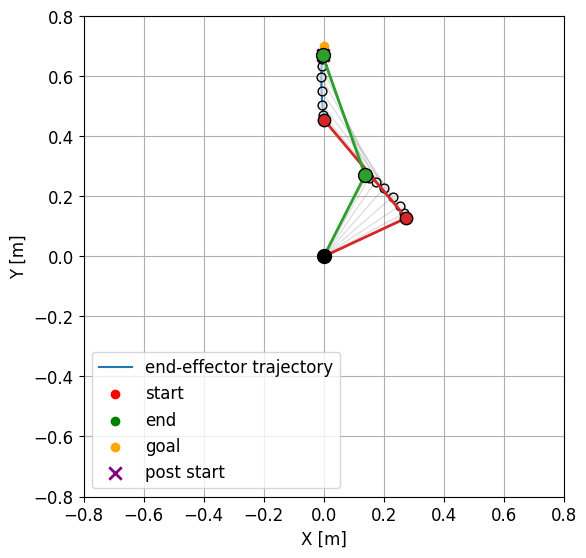

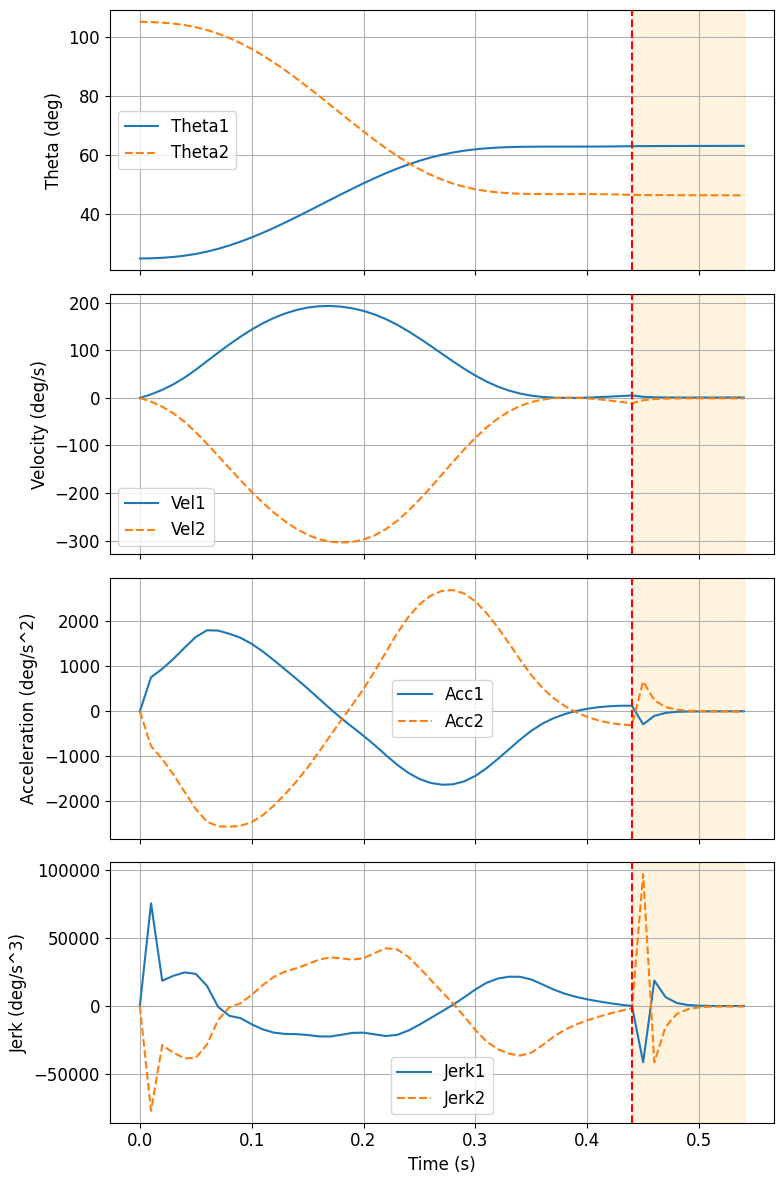

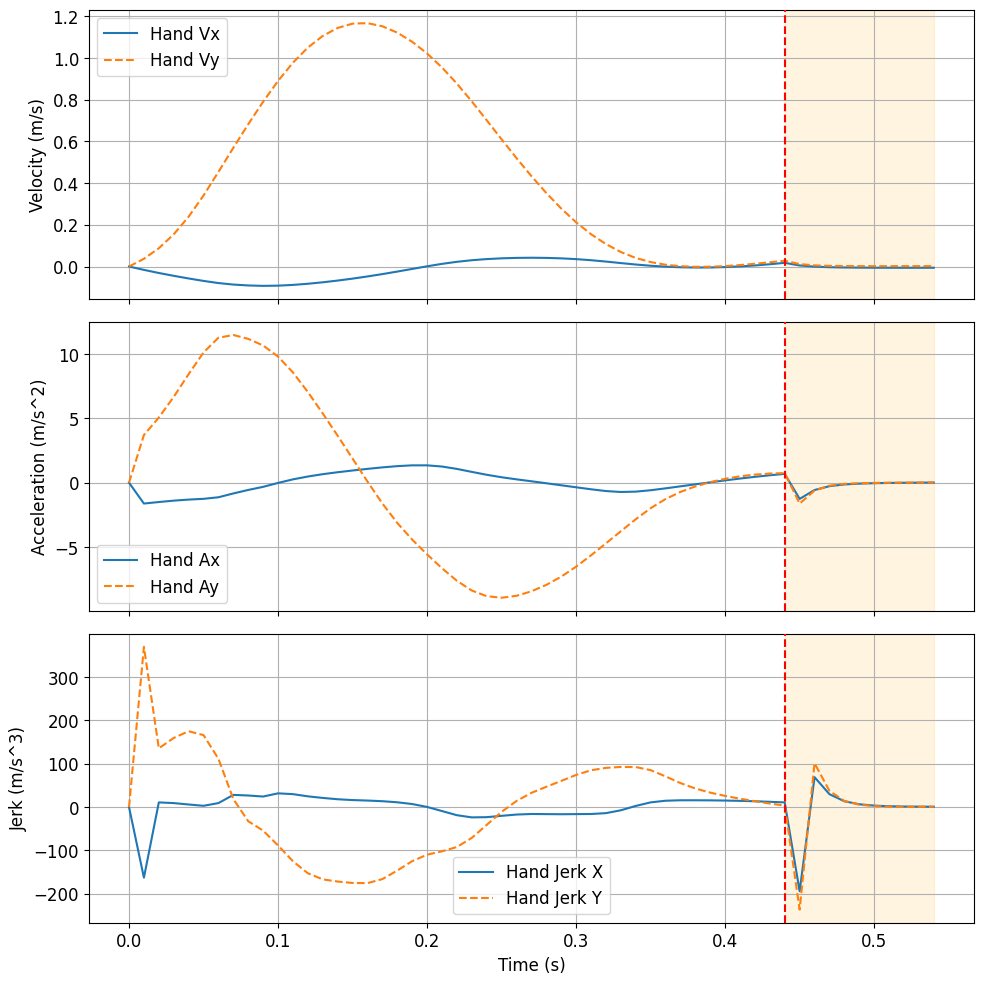

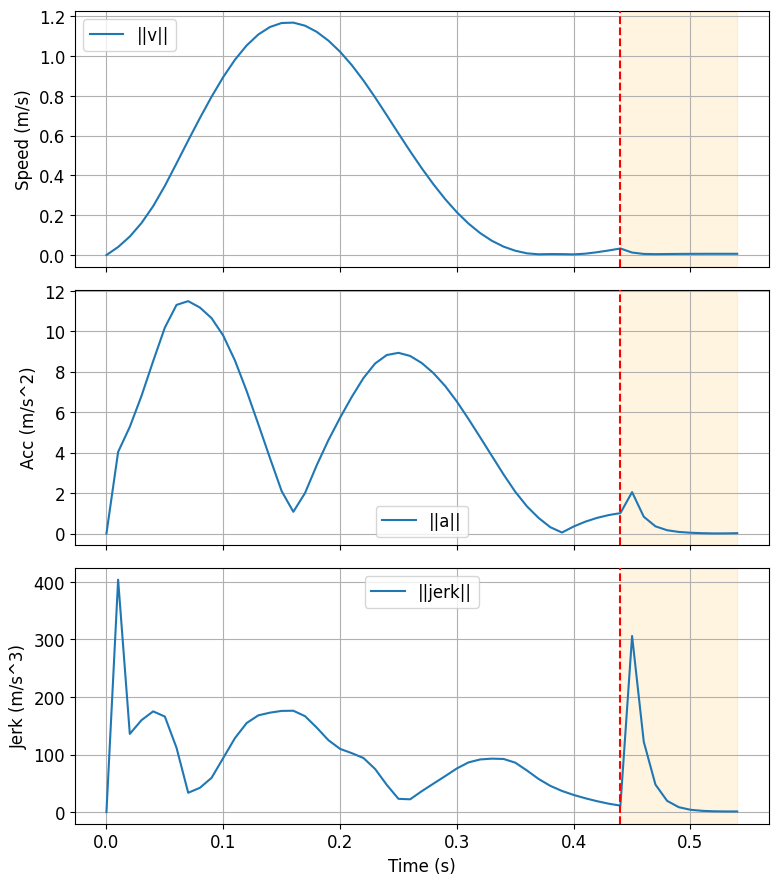

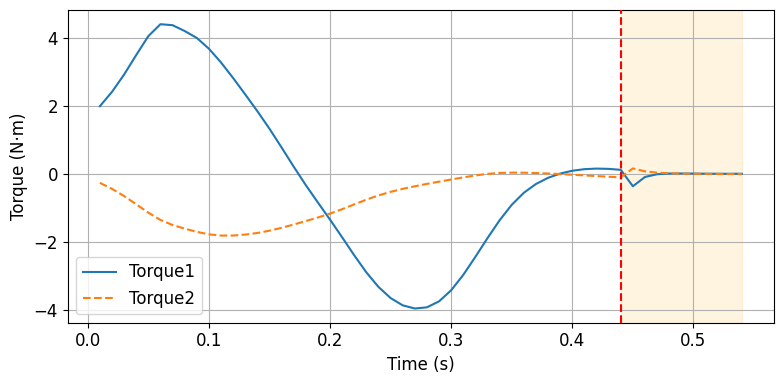

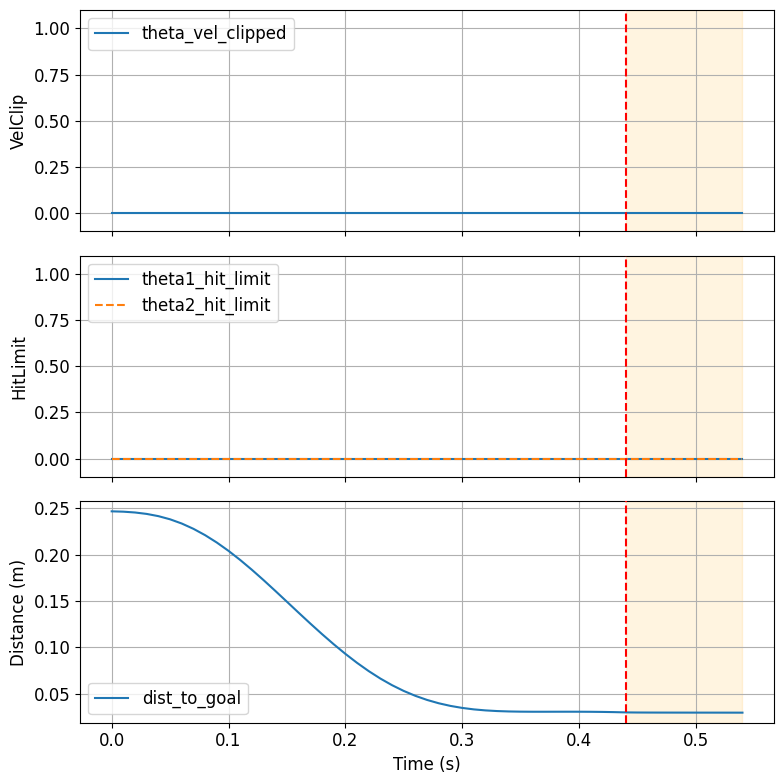

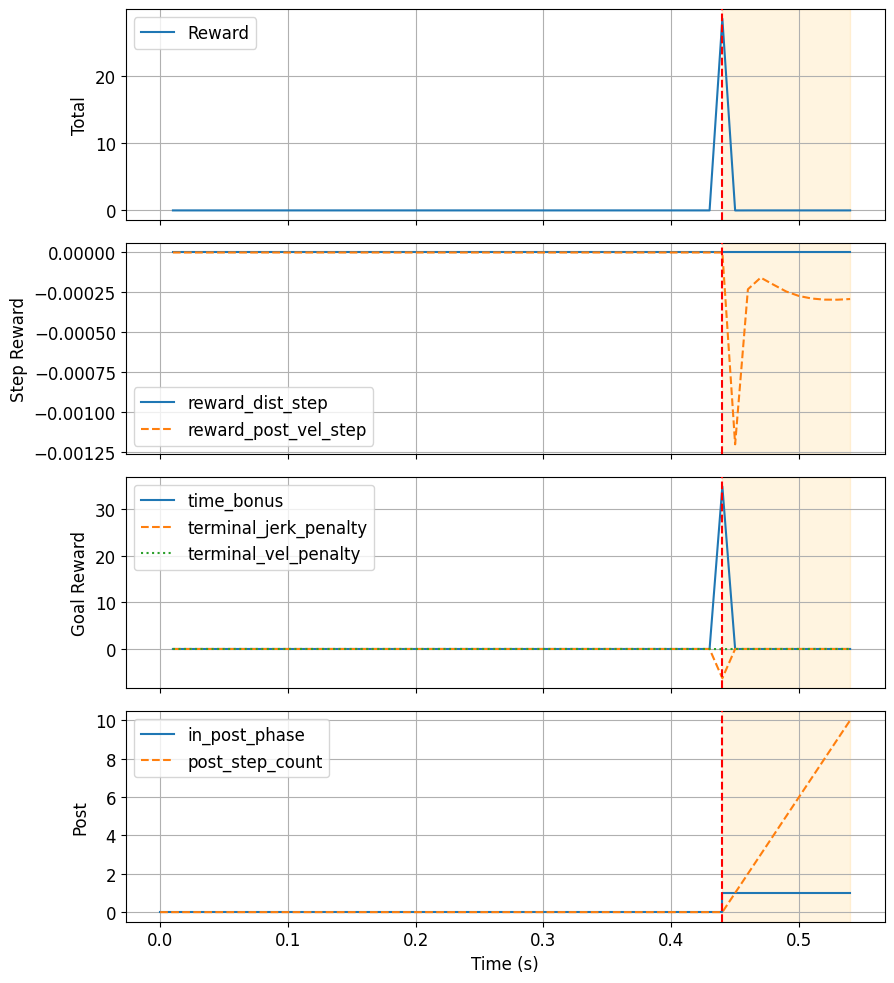

[INFO] rollout finished
  terminated = True
  truncated  = False
  final time = 0.540000
  final dist = 0.029448
  theta vel clipped ever = False
  hit limit ever = False
  reach time (from info) = 0.4400000000000002
  post start time = 0.4400000000000002
  post end time   = 0.5400000000000003


In [112]:
# =============================================================================
# 2関節アーム：1エピソード分のロールアウトをログ＋可視化するスクリプト
# （post-moving 付き現行Env対応版）
#
# 現行Envの前提:
# - 通常フェーズでは reward_dist_step
# - ゴール到達時に
#     * time_bonus
#     * terminal_jerk_penalty
#     * terminal_vel_penalty
#   が追加され、その後 post-moving phase に入る
# - post-moving phase 中は reward_post_vel_step を与える
# - info には少なくとも以下が入る想定:
#     hand_pos / hand_vel / hand_acc / hand_jerk
#     theta / theta_vel / theta_acc / theta_jerk
#     theta_vel_clipped / theta_hit_limit
#     dist_to_goal / t / action / reward_total
#     reward_dist_step / reward_post_vel_step
#     time_bonus / terminal_jerk_penalty / terminal_vel_penalty
#     in_post_phase / post_step_count / post_moving_steps / reach_time / reached_this_step
#
# 方針:
# - ロールアウトは env.step() のみで最後まで回す
# - 図は1エピソード全体を表示
# - 横軸が時間の図では、post-moving 開始時刻を縦線・色帯で明示する
# =============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 0. 設定
# -----------------------------------------------------------------------------
SAFETY_EXTRA_STEPS = 10  # 安全用の余裕 step
POST_SHADE_ALPHA = 0.12  # post区間の色帯の濃さ
POST_SHADE_COLOR = "orange"

# -----------------------------------------------------------------------------
# 1. ログ出力先フォルダ（最新ログフォルダ）を決定
# -----------------------------------------------------------------------------
logs_dir = "./logs"
os.makedirs(logs_dir, exist_ok=True)

log_folders = [
    os.path.join(logs_dir, d)
    for d in os.listdir(logs_dir)
    if os.path.isdir(os.path.join(logs_dir, d))
]

if len(log_folders) == 0:
    latest_log_folder = logs_dir
else:
    latest_log_folder = max(log_folders, key=os.path.getmtime)

print(f"[INFO] 最新ログフォルダを使用: {latest_log_folder}")

# -----------------------------------------------------------------------------
# 2. post区間を時間軸図に描く補助関数
# -----------------------------------------------------------------------------
def add_post_phase_marker(ax, post_start_time, post_end_time, label_once=True):
    """
    横軸が時間の図に対して、
    - post 開始時刻の縦線
    - post 区間の色帯
    を追加する。
    """
    if post_start_time is None or not np.isfinite(post_start_time):
        return

    ax.axvline(
        post_start_time,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="post start" if label_once else None,
        zorder=10,
    )

    if post_end_time is not None and np.isfinite(post_end_time) and post_end_time > post_start_time:
        ax.axvspan(
            post_start_time,
            post_end_time,
            color=POST_SHADE_COLOR,
            alpha=POST_SHADE_ALPHA,
            label="post-moving" if label_once else None,
            zorder=0,
        )

# -----------------------------------------------------------------------------
# 3. ログ用リスト
# -----------------------------------------------------------------------------
time_log = []

phase_log = []
in_post_phase_log = []
post_step_count_log = []
post_moving_steps_log = []
reach_time_log = []
reached_this_step_log = []

hand_x, hand_y = [], []
hand_vx_log, hand_vy_log = [], []
hand_ax_log, hand_ay_log = [], []
hand_jx_log, hand_jy_log = [], []

theta1_log, theta2_log = [], []
theta1_vel_log, theta2_vel_log = [], []
theta1_acc_log, theta2_acc_log = [], []
theta1_jerk_log, theta2_jerk_log = [], []

torque1_log, torque2_log = [], []

hand_speed_log = []
hand_acc_norm_log = []
hand_jerk_norm_log = []

reward_log = []
reward_dist_step_log = []
reward_post_vel_step_log = []
time_bonus_log = []
terminal_jerk_penalty_log = []
terminal_vel_penalty_log = []

dist_to_goal_log = []

theta_vel_clipped_log = []
theta_hit_limit_1_log = []
theta_hit_limit_2_log = []

terminated_log = []
truncated_log = []

# -----------------------------------------------------------------------------
# 4. 初期観測を取得し、t=0 をログ
# -----------------------------------------------------------------------------
obs, _ = env.reset()

dt_macro = float(getattr(env, "dt", DT))
max_steps_env = int(getattr(env, "max_steps", STEPS_MAX))
post_moving_steps_env = int(getattr(env, "post_moving_steps", 10))
MAX_STEPS_TO_RUN = max_steps_env + post_moving_steps_env + SAFETY_EXTRA_STEPS

try:
    init_theta = np.asarray(env.theta).reshape(-1)
    init_theta_vel = np.asarray(env.theta_vel).reshape(-1)
    init_theta_acc = np.asarray(env.theta_acc).reshape(-1)
    init_theta_jerk = np.asarray(env.theta_jerk).reshape(-1)

    init_hand_pos = np.asarray(getattr(env, "hand_pos", env.forward_kinematics(init_theta)))
    init_hand_vel = np.asarray(getattr(env, "hand_vel", np.zeros(2)))
    init_hand_acc = np.asarray(getattr(env, "hand_acc", np.zeros(2)))
    init_hand_jerk = np.asarray(getattr(env, "hand_jerk", np.zeros(2)))
except Exception:
    init_theta = np.array([np.radians(THETA_INIT), np.radians(THETA_INIT)], dtype=np.float32)
    init_theta_vel = np.zeros(2, dtype=np.float32)
    init_theta_acc = np.zeros(2, dtype=np.float32)
    init_theta_jerk = np.zeros(2, dtype=np.float32)

    init_hand_pos = np.asarray(getattr(env, "hand_pos", np.array([0.0, 0.0])))
    init_hand_vel = np.zeros(2, dtype=np.float32)
    init_hand_acc = np.zeros(2, dtype=np.float32)
    init_hand_jerk = np.zeros(2, dtype=np.float32)

t = 0.0

time_log.append(t)

phase_log.append("main")
in_post_phase_log.append(0)
post_step_count_log.append(0)
post_moving_steps_log.append(post_moving_steps_env)
reach_time_log.append(np.nan)
reached_this_step_log.append(0)

hand_x.append(float(init_hand_pos[0]))
hand_y.append(float(init_hand_pos[1]))

hand_vx_log.append(float(init_hand_vel[0]))
hand_vy_log.append(float(init_hand_vel[1]))
hand_ax_log.append(float(init_hand_acc[0]))
hand_ay_log.append(float(init_hand_acc[1]))
hand_jx_log.append(float(init_hand_jerk[0]))
hand_jy_log.append(float(init_hand_jerk[1]))

theta1_log.append(np.degrees(init_theta[0]))
theta2_log.append(np.degrees(init_theta[1]))
theta1_vel_log.append(np.degrees(init_theta_vel[0]))
theta2_vel_log.append(np.degrees(init_theta_vel[1]))
theta1_acc_log.append(np.degrees(init_theta_acc[0]))
theta2_acc_log.append(np.degrees(init_theta_acc[1]))
theta1_jerk_log.append(np.degrees(init_theta_jerk[0]))
theta2_jerk_log.append(np.degrees(init_theta_jerk[1]))

torque1_log.append(np.nan)
torque2_log.append(np.nan)

hand_speed_log.append(float(np.linalg.norm(init_hand_vel)))
hand_acc_norm_log.append(float(np.linalg.norm(init_hand_acc)))
hand_jerk_norm_log.append(float(np.linalg.norm(init_hand_jerk)))

reward_log.append(np.nan)
reward_dist_step_log.append(np.nan)
reward_post_vel_step_log.append(np.nan)
time_bonus_log.append(np.nan)
terminal_jerk_penalty_log.append(np.nan)
terminal_vel_penalty_log.append(np.nan)

dist_to_goal_log.append(float(np.linalg.norm(init_hand_pos - getattr(env, "goal_pos", np.zeros(2)))))

theta_vel_clipped_log.append(0)
theta_hit_limit_1_log.append(0)
theta_hit_limit_2_log.append(0)

terminated_log.append(0)
truncated_log.append(0)

# -----------------------------------------------------------------------------
# 5. ロールアウト本体
# -----------------------------------------------------------------------------
end_time = None

for _ in range(MAX_STEPS_TO_RUN):
    action, _ = model.predict(obs, deterministic=True)
    action = np.asarray(action).reshape(-1)
    if action.shape[0] != 2:
        raise RuntimeError(f"model.predict returned wrong action shape: {action.shape}, expected (2,)")

    obs, reward, terminated, truncated, info = env.step(action)
    if info is None:
        info = {}

    t += dt_macro

    hand_pos = np.asarray(info.get("hand_pos", getattr(env, "hand_pos", np.array([0.0, 0.0]))))
    hand_vel = np.asarray(info.get("hand_vel", getattr(env, "hand_vel", np.zeros(2))))
    hand_acc = np.asarray(info.get("hand_acc", getattr(env, "hand_acc", np.zeros(2))))
    hand_jerk = np.asarray(info.get("hand_jerk", getattr(env, "hand_jerk", np.zeros(2))))

    theta = np.asarray(info.get("theta", getattr(env, "theta", np.zeros(2))))
    theta_vel = np.asarray(info.get("theta_vel", getattr(env, "theta_vel", np.zeros(2))))
    theta_acc = np.asarray(info.get("theta_acc", getattr(env, "theta_acc", np.zeros(2))))
    theta_jerk = np.asarray(info.get("theta_jerk", getattr(env, "theta_jerk", np.zeros(2))))

    action_info = np.asarray(info.get("action", action))
    theta_hit_limit = np.asarray(info.get("theta_hit_limit", np.array([False, False]))).reshape(-1)

    in_post_phase = bool(info.get("in_post_phase", False))
    post_step_count = int(info.get("post_step_count", 0))
    post_moving_steps = int(info.get("post_moving_steps", post_moving_steps_env))
    reach_time_val = info.get("reach_time", np.nan)
    reached_this_step = int(bool(info.get("reached_this_step", False)))

    time_log.append(t)

    phase_log.append("post" if in_post_phase else "main")
    in_post_phase_log.append(int(in_post_phase))
    post_step_count_log.append(post_step_count)
    post_moving_steps_log.append(post_moving_steps)
    reach_time_log.append(float(reach_time_val) if reach_time_val is not None else np.nan)
    reached_this_step_log.append(reached_this_step)

    hand_x.append(float(hand_pos[0]))
    hand_y.append(float(hand_pos[1]))

    hand_vx_log.append(float(hand_vel[0]))
    hand_vy_log.append(float(hand_vel[1]))
    hand_ax_log.append(float(hand_acc[0]))
    hand_ay_log.append(float(hand_acc[1]))
    hand_jx_log.append(float(hand_jerk[0]))
    hand_jy_log.append(float(hand_jerk[1]))

    theta1_log.append(np.degrees(theta[0]))
    theta2_log.append(np.degrees(theta[1]))
    theta1_vel_log.append(np.degrees(theta_vel[0]))
    theta2_vel_log.append(np.degrees(theta_vel[1]))
    theta1_acc_log.append(np.degrees(theta_acc[0]))
    theta2_acc_log.append(np.degrees(theta_acc[1]))
    theta1_jerk_log.append(np.degrees(theta_jerk[0]))
    theta2_jerk_log.append(np.degrees(theta_jerk[1]))

    torque1_log.append(float(action_info[0]))
    torque2_log.append(float(action_info[1]))

    hand_speed_log.append(float(np.linalg.norm(hand_vel)))
    hand_acc_norm_log.append(float(np.linalg.norm(hand_acc)))
    hand_jerk_norm_log.append(float(np.linalg.norm(hand_jerk)))

    reward_log.append(float(reward))
    reward_dist_step_log.append(float(info.get("reward_dist_step", np.nan)))
    reward_post_vel_step_log.append(float(info.get("reward_post_vel_step", np.nan)))
    time_bonus_log.append(float(info.get("time_bonus", np.nan)))
    terminal_jerk_penalty_log.append(float(info.get("terminal_jerk_penalty", np.nan)))
    terminal_vel_penalty_log.append(float(info.get("terminal_vel_penalty", np.nan)))

    dist_to_goal_log.append(float(info.get("dist_to_goal", np.nan)))

    theta_vel_clipped_log.append(int(bool(info.get("theta_vel_clipped", False))))
    theta_hit_limit_1_log.append(int(bool(theta_hit_limit[0])) if len(theta_hit_limit) > 0 else 0)
    theta_hit_limit_2_log.append(int(bool(theta_hit_limit[1])) if len(theta_hit_limit) > 1 else 0)

    terminated_log.append(int(bool(terminated)))
    truncated_log.append(int(bool(truncated)))

    if bool(terminated) or bool(truncated):
        end_time = t
        break

if end_time is None:
    end_time = t
    print("[WARN] SAFETY MAX_STEPS_TO_RUN に達したためロールアウトを打ち切りました。")

# -----------------------------------------------------------------------------
# 6. post開始・終了時刻を決定
# -----------------------------------------------------------------------------
post_start_time = np.nan
post_end_time = np.nan

if np.any(np.array(in_post_phase_log, dtype=bool)):
    first_post_idx = int(np.argmax(np.array(in_post_phase_log, dtype=bool)))
    post_start_time = float(time_log[first_post_idx])
    post_end_time = float(time_log[-1])

# reach_time があるなら、参考としてそれも使う
reach_time_series = np.asarray(reach_time_log, dtype=np.float64)
finite_reach = reach_time_series[np.isfinite(reach_time_series)]
if finite_reach.size > 0:
    reach_time_from_info = float(finite_reach[0])
else:
    reach_time_from_info = np.nan

# -----------------------------------------------------------------------------
# 7. DataFrame にまとめて CSV 保存
# -----------------------------------------------------------------------------
df = pd.DataFrame({
    "Time": time_log,

    "Phase": phase_log,
    "InPostPhase": in_post_phase_log,
    "PostStepCount": post_step_count_log,
    "PostMovingSteps": post_moving_steps_log,
    "ReachTime": reach_time_log,
    "ReachedThisStep": reached_this_step_log,

    "HandX": hand_x,
    "HandY": hand_y,

    "HandVx (m/s)": hand_vx_log,
    "HandVy (m/s)": hand_vy_log,
    "HandSpeed (m/s)": hand_speed_log,

    "HandAx (m/s^2)": hand_ax_log,
    "HandAy (m/s^2)": hand_ay_log,
    "HandAcc (m/s^2)": hand_acc_norm_log,

    "HandJerkX (m/s^3)": hand_jx_log,
    "HandJerkY (m/s^3)": hand_jy_log,
    "HandJerkNorm (m/s^3)": hand_jerk_norm_log,

    "Theta1 (deg)": theta1_log,
    "Theta2 (deg)": theta2_log,
    "Theta1_vel (deg/s)": theta1_vel_log,
    "Theta2_vel (deg/s)": theta2_vel_log,
    "Theta1_acc (deg/s^2)": theta1_acc_log,
    "Theta2_acc (deg/s^2)": theta2_acc_log,
    "Theta1_jerk (deg/s^3)": theta1_jerk_log,
    "Theta2_jerk (deg/s^3)": theta2_jerk_log,

    "Torque1 (N·m)": torque1_log,
    "Torque2 (N·m)": torque2_log,

    "Reward": reward_log,
    "RewardDistStep": reward_dist_step_log,
    "RewardPostVelStep": reward_post_vel_step_log,
    "TimeBonus": time_bonus_log,
    "TerminalJerkPenalty": terminal_jerk_penalty_log,
    "TerminalVelPenalty": terminal_vel_penalty_log,

    "DistToGoal": dist_to_goal_log,

    "ThetaVelClipped": theta_vel_clipped_log,
    "Theta1HitLimit": theta_hit_limit_1_log,
    "Theta2HitLimit": theta_hit_limit_2_log,

    "Terminated": terminated_log,
    "Truncated": truncated_log,
})

output_folder = latest_log_folder
os.makedirs(output_folder, exist_ok=True)
base_filename = os.path.join(output_folder, "end_result_2joint_post_env")

csv_path = f"{base_filename}.csv"
df.to_csv(csv_path, index=False)
print(f"[INFO] CSV 保存: {csv_path}")

# -----------------------------------------------------------------------------
# 8. 可視化①: 手先軌道 + アーム姿勢
# -----------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(6, 6))

ax1.plot(df["HandX"], df["HandY"], linestyle="-", linewidth=1.5, label="end-effector trajectory")
ax1.scatter(df["HandX"].iloc[0], df["HandY"].iloc[0], color="red", label="start", zorder=5)
ax1.scatter(df["HandX"].iloc[-1], df["HandY"].iloc[-1], color="green", label="end", zorder=5)
ax1.scatter(float(getattr(env, "goal_pos", np.array([0.0, 0.0]))[0]),
            float(getattr(env, "goal_pos", np.array([0.0, 0.0]))[1]),
            color="orange", label="goal", zorder=5)

# post開始位置を軌道上に表示
if np.isfinite(post_start_time):
    post_start_idx = int(np.argmax(np.array(in_post_phase_log, dtype=bool)))
    ax1.scatter(
        df["HandX"].iloc[post_start_idx],
        df["HandY"].iloc[post_start_idx],
        color="purple",
        s=80,
        marker="x",
        linewidths=2,
        label="post start",
        zorder=6
    )

try:
    l1 = float(getattr(env, "l1", L1))
    l2 = float(getattr(env, "l2", L2))
except Exception:
    l1 = L1
    l2 = L2

theta1_rad = np.radians(df["Theta1 (deg)"].values)
theta2_rad = np.radians(df["Theta2 (deg)"].values)

x1 = l1 * np.cos(theta1_rad)
y1 = l1 * np.sin(theta1_rad)
x2 = x1 + l2 * np.cos(theta1_rad + theta2_rad)
y2 = y1 + l2 * np.sin(theta1_rad + theta2_rad)

N_POSES = min(15, len(df))
indices = np.linspace(0, len(df) - 1, N_POSES).astype(int)

for idx in indices:
    xs_pose = [0.0, x1[idx], x2[idx]]
    ys_pose = [0.0, y1[idx], y2[idx]]
    ax1.plot(xs_pose, ys_pose, linewidth=1, color=(0.5, 0.5, 0.5, 0.25), solid_capstyle='round')
    ax1.scatter(
        [xs_pose[1], xs_pose[2]],
        [ys_pose[1], ys_pose[2]],
        s=40,
        edgecolors='k',
        facecolors=(0.9, 0.9, 0.9, 0.6),
        zorder=4
    )

i0 = 0
xs0 = [0.0, x1[i0], x2[i0]]
ys0 = [0.0, y1[i0], y2[i0]]
ax1.plot(xs0, ys0, linewidth=2, color='tab:red', solid_capstyle='round', zorder=6)
ax1.scatter([xs0[1], xs0[2]], [ys0[1], ys0[2]], s=80, color='tab:red', edgecolors='k', zorder=7)
ax1.scatter(0.0, 0.0, s=100, color='black', zorder=8)

ie = len(df) - 1
xse = [0.0, x1[ie], x2[ie]]
yse = [0.0, y1[ie], y2[ie]]
ax1.plot(xse, yse, linewidth=2, color='tab:green', solid_capstyle='round', zorder=6)
ax1.scatter([xse[1], xse[2]], [yse[1], yse[2]], s=100, color='tab:green', edgecolors='k', zorder=7)

ax1.set_xlabel("X [m]")
ax1.set_ylabel("Y [m]")
ax1.grid(True)
ax1.legend()
ax1.set_aspect('equal', adjustable='box')

reach = l1 + l2
ax1.set_xlim(-reach - 0.1 * reach, reach + 0.1 * reach)
ax1.set_ylim(-reach - 0.1 * reach, reach + 0.1 * reach)

plt.tight_layout()
plt.savefig(f"{base_filename}_trajectory_with_arms.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 9. 可視化②: 関節動的変数
# -----------------------------------------------------------------------------
fig2, axes = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

axes[0].plot(df["Time"], df["Theta1 (deg)"], label="Theta1")
axes[0].plot(df["Time"], df["Theta2 (deg)"], linestyle="--", label="Theta2")
axes[0].set_ylabel("Theta (deg)")
axes[0].legend()
axes[0].grid()

axes[1].plot(df["Time"], df["Theta1_vel (deg/s)"], label="Vel1")
axes[1].plot(df["Time"], df["Theta2_vel (deg/s)"], linestyle="--", label="Vel2")
axes[1].set_ylabel("Velocity (deg/s)")
axes[1].legend()
axes[1].grid()

axes[2].plot(df["Time"], df["Theta1_acc (deg/s^2)"], label="Acc1")
axes[2].plot(df["Time"], df["Theta2_acc (deg/s^2)"], linestyle="--", label="Acc2")
axes[2].set_ylabel("Acceleration (deg/s^2)")
axes[2].legend()
axes[2].grid()

axes[3].plot(df["Time"], df["Theta1_jerk (deg/s^3)"], label="Jerk1")
axes[3].plot(df["Time"], df["Theta2_jerk (deg/s^3)"], linestyle="--", label="Jerk2")
axes[3].set_ylabel("Jerk (deg/s^3)")
axes[3].set_xlabel("Time (s)")
axes[3].legend()
axes[3].grid()

for i, ax in enumerate(axes):
    add_post_phase_marker(ax, post_start_time, post_end_time, label_once=(i == 0))

plt.tight_layout()
plt.savefig(f"{base_filename}_joint_dynamics.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 10. 可視化③A: 手先速度・加速度・躍度（x / y 成分）
# -----------------------------------------------------------------------------
fig3a, ax3a = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax3a[0].plot(df["Time"], df["HandVx (m/s)"], label="Hand Vx")
ax3a[0].plot(df["Time"], df["HandVy (m/s)"], linestyle="--", label="Hand Vy")
ax3a[0].set_ylabel("Velocity (m/s)")
ax3a[0].legend()
ax3a[0].grid()

ax3a[1].plot(df["Time"], df["HandAx (m/s^2)"], label="Hand Ax")
ax3a[1].plot(df["Time"], df["HandAy (m/s^2)"], linestyle="--", label="Hand Ay")
ax3a[1].set_ylabel("Acceleration (m/s^2)")
ax3a[1].legend()
ax3a[1].grid()

ax3a[2].plot(df["Time"], df["HandJerkX (m/s^3)"], label="Hand Jerk X")
ax3a[2].plot(df["Time"], df["HandJerkY (m/s^3)"], linestyle="--", label="Hand Jerk Y")
ax3a[2].set_ylabel("Jerk (m/s^3)")
ax3a[2].set_xlabel("Time (s)")
ax3a[2].legend()
ax3a[2].grid()

for i, ax in enumerate(ax3a):
    add_post_phase_marker(ax, post_start_time, post_end_time, label_once=(i == 0))

plt.tight_layout()
plt.savefig(f"{base_filename}_hand_xy_components.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 11. 可視化③B: 手先速度・加速度・躍度（ノルム）
# -----------------------------------------------------------------------------
fig3b, ax3b = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

ax3b[0].plot(df["Time"], df["HandSpeed (m/s)"], label="||v||")
ax3b[0].set_ylabel("Speed (m/s)")
ax3b[0].legend()
ax3b[0].grid()

ax3b[1].plot(df["Time"], df["HandAcc (m/s^2)"], label="||a||")
ax3b[1].set_ylabel("Acc (m/s^2)")
ax3b[1].legend()
ax3b[1].grid()

ax3b[2].plot(df["Time"], df["HandJerkNorm (m/s^3)"], label="||jerk||")
ax3b[2].set_ylabel("Jerk (m/s^3)")
ax3b[2].set_xlabel("Time (s)")
ax3b[2].legend()
ax3b[2].grid()

for i, ax in enumerate(ax3b):
    add_post_phase_marker(ax, post_start_time, post_end_time, label_once=(i == 0))

plt.tight_layout()
plt.savefig(f"{base_filename}_hand_norms.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 12. 可視化④: トルク
# -----------------------------------------------------------------------------
fig4, ax4 = plt.subplots(1, 1, figsize=(8, 4), sharex=True)

ax4.plot(df["Time"], df["Torque1 (N·m)"], label="Torque1")
ax4.plot(df["Time"], df["Torque2 (N·m)"], linestyle="--", label="Torque2")
ax4.set_ylabel("Torque (N·m)")
ax4.set_xlabel("Time (s)")
ax4.legend()
ax4.grid()

add_post_phase_marker(ax4, post_start_time, post_end_time, label_once=True)

plt.tight_layout()
plt.savefig(f"{base_filename}_torques.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 13. 可視化⑤: 制限イベント + 距離
# -----------------------------------------------------------------------------
fig5, ax5 = plt.subplots(3, 1, figsize=(8, 8), sharex=True)

ax5[0].step(df["Time"], df["ThetaVelClipped"], where="post", label="theta_vel_clipped")
ax5[0].set_ylabel("VelClip")
ax5[0].set_ylim(-0.1, 1.1)
ax5[0].legend()
ax5[0].grid()

ax5[1].step(df["Time"], df["Theta1HitLimit"], where="post", label="theta1_hit_limit")
ax5[1].step(df["Time"], df["Theta2HitLimit"], where="post", linestyle="--", label="theta2_hit_limit")
ax5[1].set_ylabel("HitLimit")
ax5[1].set_ylim(-0.1, 1.1)
ax5[1].legend()
ax5[1].grid()

ax5[2].plot(df["Time"], df["DistToGoal"], label="dist_to_goal")
ax5[2].set_ylabel("Distance (m)")
ax5[2].set_xlabel("Time (s)")
ax5[2].legend()
ax5[2].grid()

for i, ax in enumerate(ax5):
    add_post_phase_marker(ax, post_start_time, post_end_time, label_once=(i == 0))

plt.tight_layout()
plt.savefig(f"{base_filename}_limit_events.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 14. 可視化⑥: 報酬内訳
# -----------------------------------------------------------------------------
fig6, ax6 = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

ax6[0].plot(df["Time"], df["Reward"], label="Reward")
ax6[0].set_ylabel("Total")
ax6[0].legend()
ax6[0].grid()

ax6[1].plot(df["Time"], df["RewardDistStep"], label="reward_dist_step")
ax6[1].plot(df["Time"], df["RewardPostVelStep"], label="reward_post_vel_step", linestyle="--")
ax6[1].set_ylabel("Step Reward")
ax6[1].legend()
ax6[1].grid()

ax6[2].plot(df["Time"], df["TimeBonus"], label="time_bonus")
ax6[2].plot(df["Time"], df["TerminalJerkPenalty"], label="terminal_jerk_penalty", linestyle="--")
ax6[2].plot(df["Time"], df["TerminalVelPenalty"], label="terminal_vel_penalty", linestyle=":")
ax6[2].set_ylabel("Goal Reward")
ax6[2].legend()
ax6[2].grid()

ax6[3].step(df["Time"], df["InPostPhase"], where="post", label="in_post_phase")
ax6[3].plot(df["Time"], df["PostStepCount"], label="post_step_count", linestyle="--")
ax6[3].set_ylabel("Post")
ax6[3].set_xlabel("Time (s)")
ax6[3].legend()
ax6[3].grid()

for i, ax in enumerate(ax6):
    add_post_phase_marker(ax, post_start_time, post_end_time, label_once=(i == 0))

plt.tight_layout()
plt.savefig(f"{base_filename}_reward_breakdown.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 15. 参考表示
# -----------------------------------------------------------------------------
final_row = df.iloc[-1]
print("[INFO] rollout finished")
print(f"  terminated = {bool(final_row['Terminated'])}")
print(f"  truncated  = {bool(final_row['Truncated'])}")
print(f"  final time = {final_row['Time']:.6f}")
print(f"  final dist = {final_row['DistToGoal']:.6f}")
print(f"  theta vel clipped ever = {bool(df['ThetaVelClipped'].max())}")
print(f"  hit limit ever = {bool(df['Theta1HitLimit'].max()) or bool(df['Theta2HitLimit'].max())}")
print(f"  reach time (from info) = {reach_time_from_info}")
print(f"  post start time = {post_start_time}")
print(f"  post end time   = {post_end_time}")

## ベストモデルの活用

[INFO] 最新のモデルファイルを使用: ./logs/2026_04_28_15_35_25/best_model.zip
[INFO] 最新ログフォルダ: ./logs/2026_04_28_15_35_25
[INFO] モデルを PPO 形式でロードしました。
[INFO] CSV 保存: ./logs/2026_04_28_15_35_25/best_result_2joint_post_env.csv


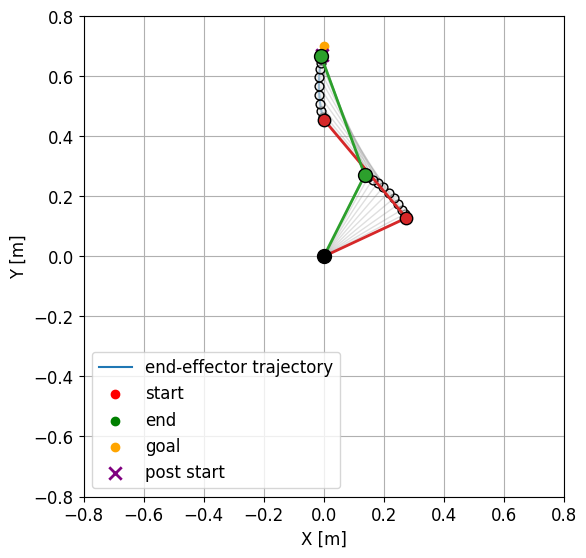

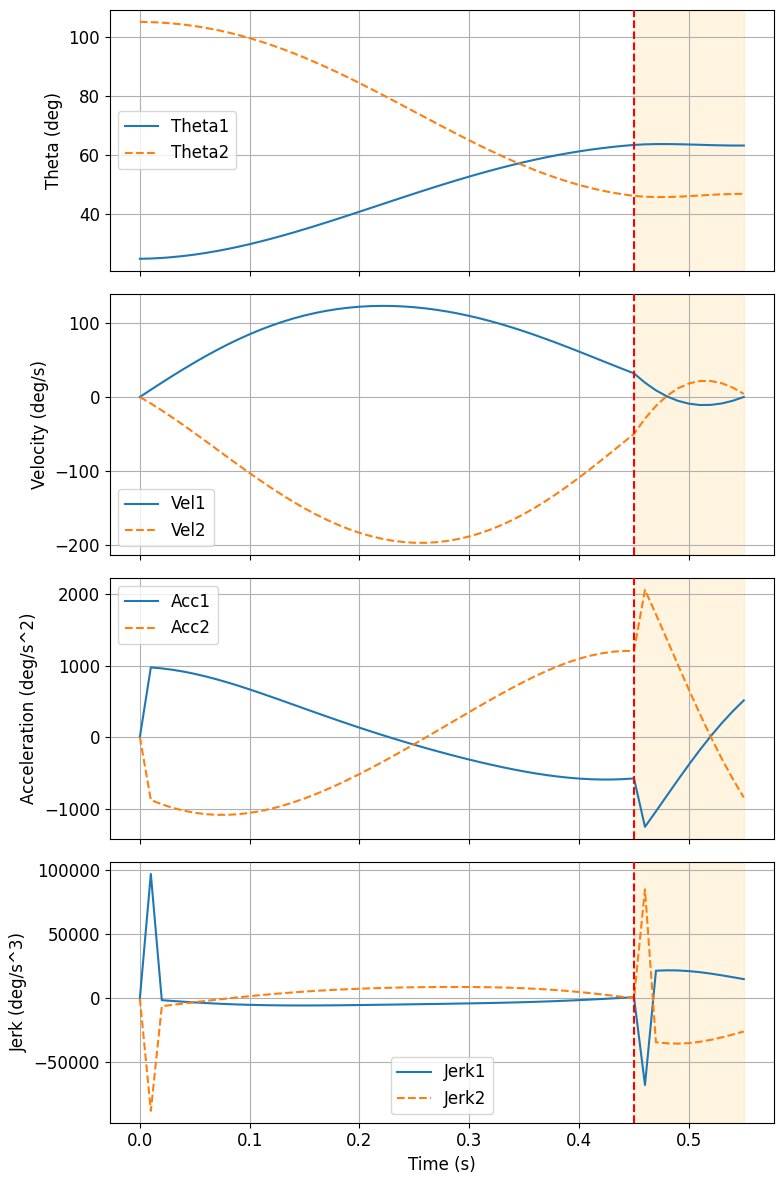

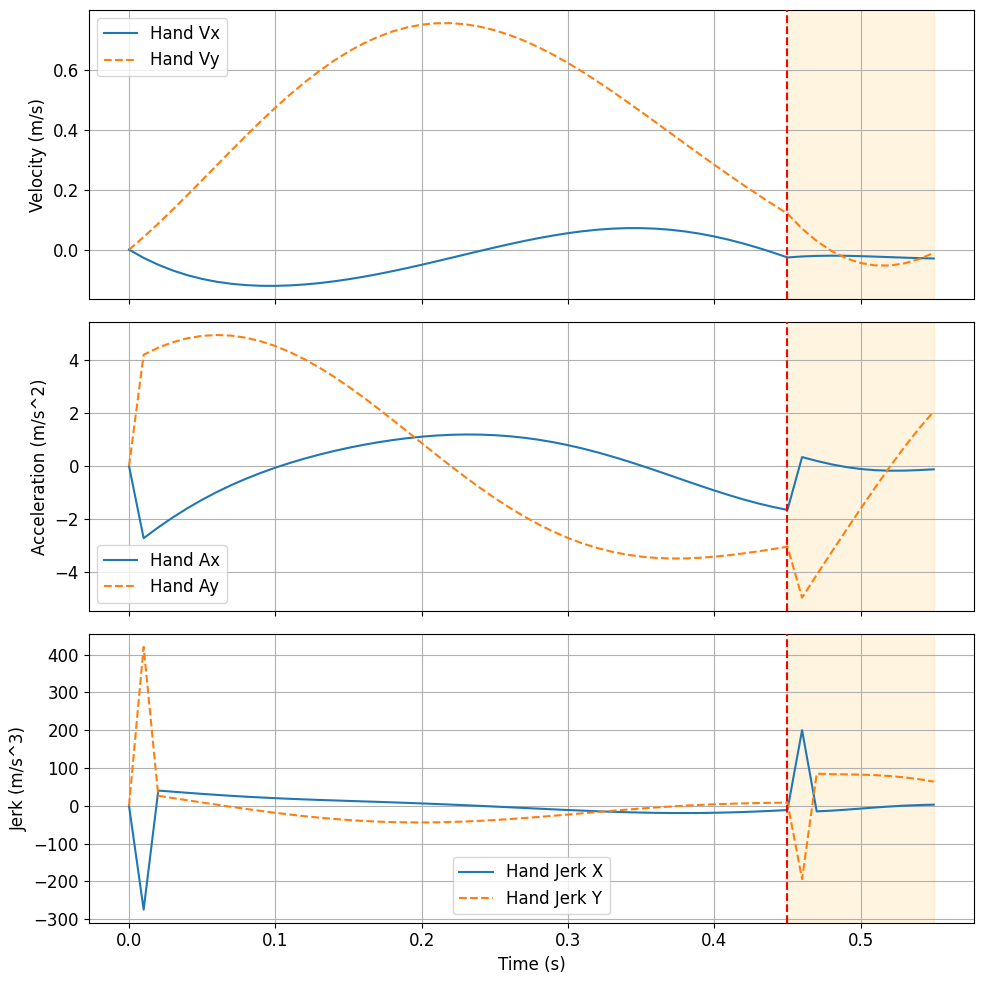

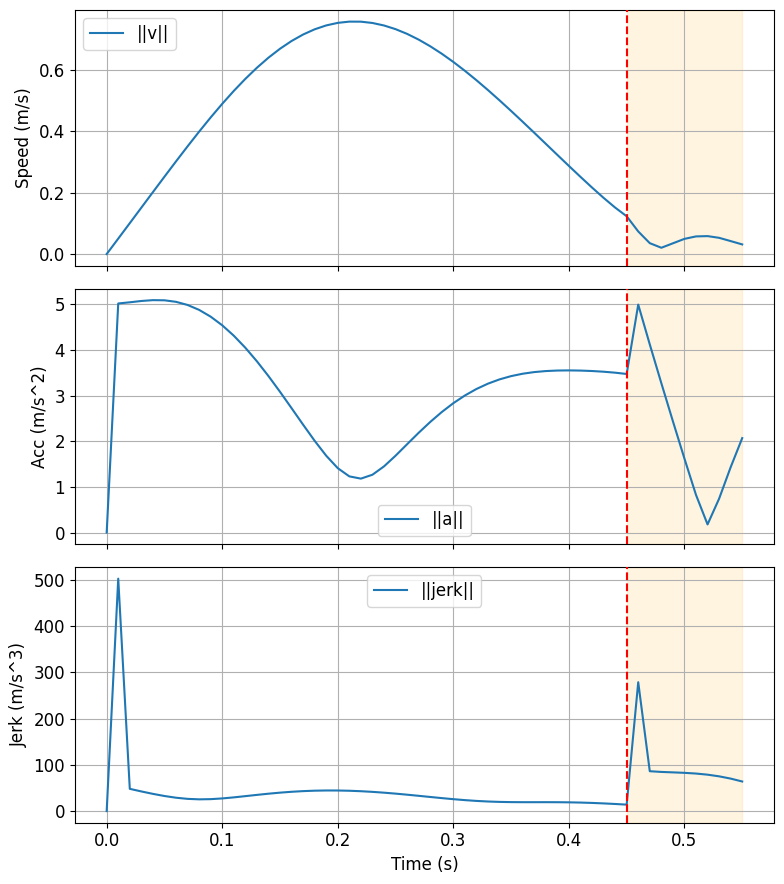

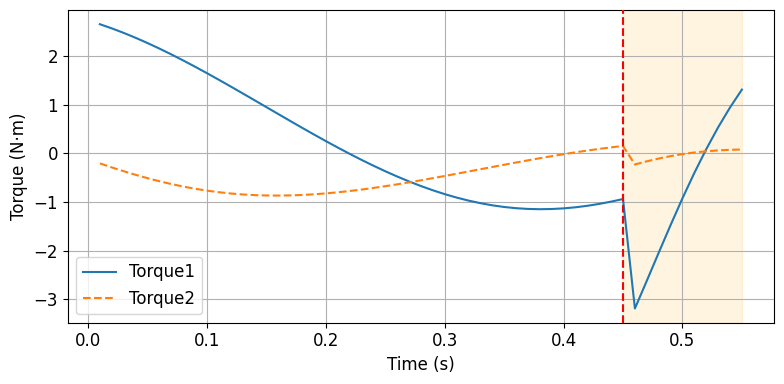

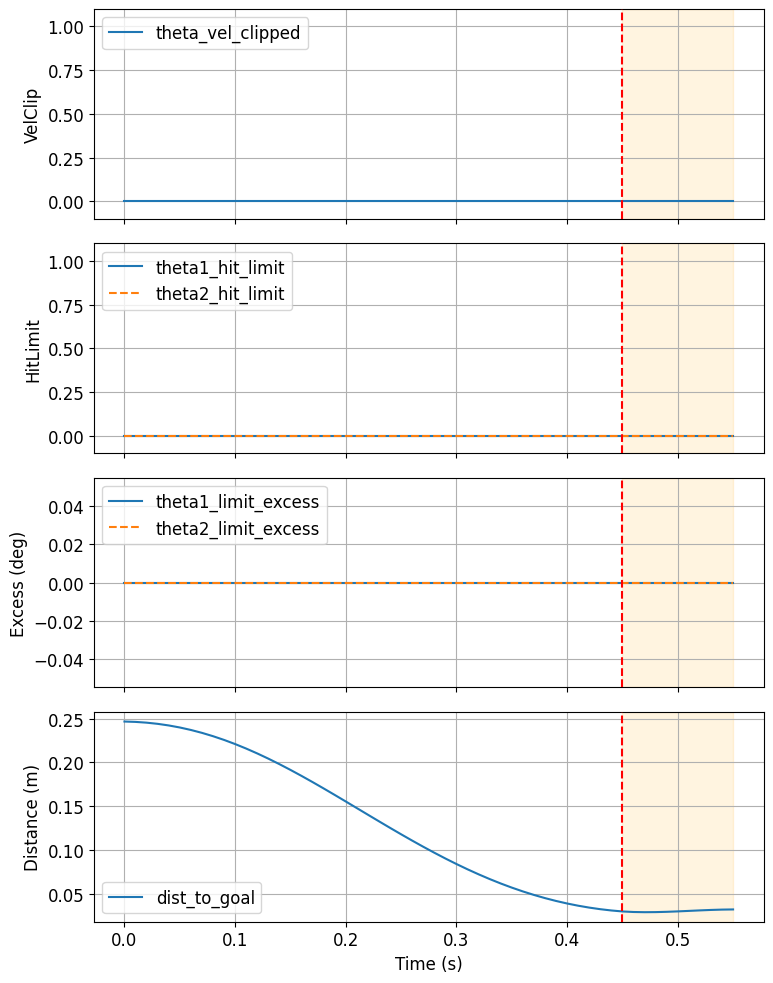

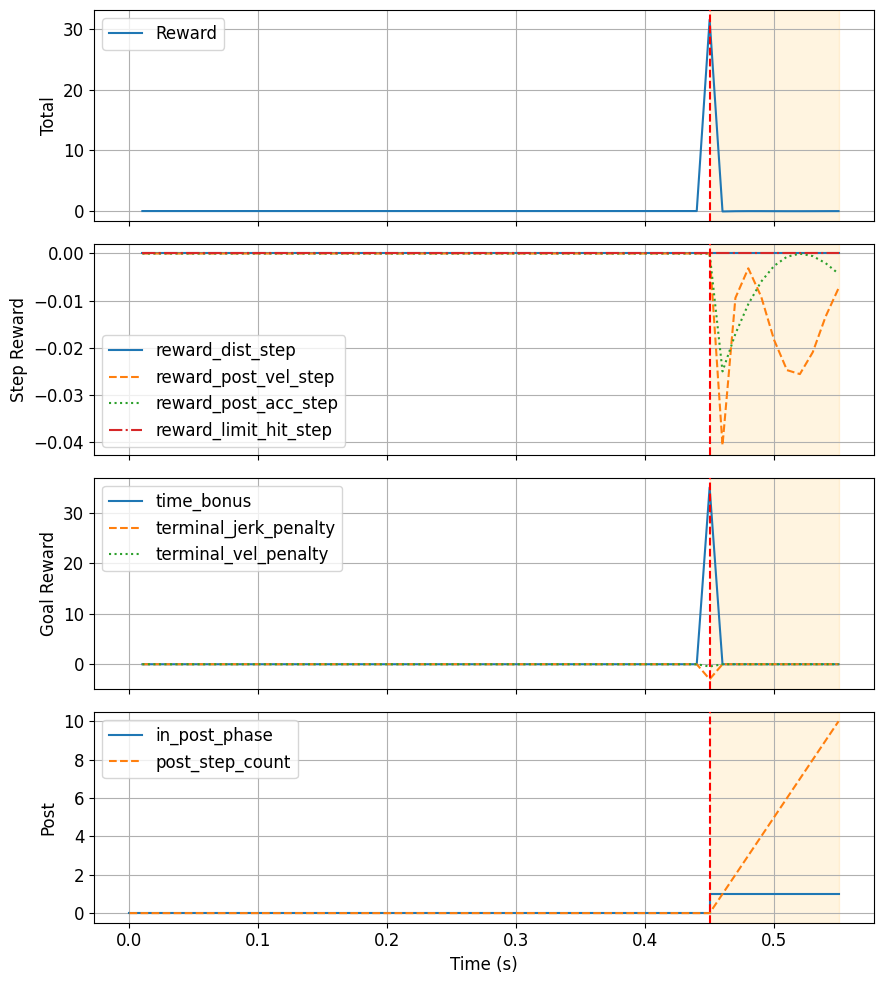

[INFO] rollout finished
  terminated = True
  truncated  = False
  final time = 0.550000
  final dist = 0.032153
  theta vel clipped ever = False
  hit limit ever = False
  reach time (from info) = 0.45000000000000023
  post start time = 0.45000000000000023
  post end time   = 0.5500000000000003


In [113]:
# =============================================================================
# best_model ロード ＋ 1エピソード分のロールアウトをログ＋可視化するスクリプト
# （post-moving 付き現行Env対応版）
# =============================================================================
#
# 現行Envの前提:
# - 通常フェーズでは reward_dist_step
# - ゴール到達時に
#     * time_bonus
#     * terminal_jerk_penalty
#     * terminal_vel_penalty
#   が追加され、その後 post-moving phase に入る
# - post-moving phase 中は
#     * reward_post_vel_step
#     * （ある場合）reward_post_acc_step
#   が加算される
# - 関節角度超過に対する補助報酬として
#     * （ある場合）reward_limit_hit_step
#   が入る
# - info には少なくとも以下が入る想定:
#     hand_pos / hand_vel / hand_acc / hand_jerk
#     theta / theta_vel / theta_acc / theta_jerk
#     theta_vel_clipped / theta_hit_limit
#     dist_to_goal / t / action / reward_total
#     reward_dist_step / reward_post_vel_step
#     time_bonus / terminal_jerk_penalty / terminal_vel_penalty
#     in_post_phase / post_step_count / post_moving_steps / reach_time / reached_this_step
#
# 方針:
# - 最新ログフォルダから best_model.zip（なければ最新 .zip）を自動検出
# - SB3 アルゴリズム種別を自動推定してロード
# - env を使って 1 エピソードだけロールアウト
# - 図は 1 エピソード全体を表示
# - 横軸が時間の図では、post-moving 開始時刻を縦線・色帯で明示する
# =============================================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from stable_baselines3 import PPO, SAC, TD3, DDPG, A2C

# -----------------------------------------------------------------------------
# 0) 設定
# -----------------------------------------------------------------------------
SAFETY_EXTRA_STEPS = 10
POST_SHADE_ALPHA = 0.12
POST_SHADE_COLOR = "orange"

# -----------------------------------------------------------------------------
# 1) 最新ログフォルダを見つけ、best_model.zip を探す
# -----------------------------------------------------------------------------
log_base = "./logs"
log_dirs = [d for d in glob.glob(os.path.join(log_base, "*")) if os.path.isdir(d)]
if not log_dirs:
    raise FileNotFoundError("logs フォルダにサブディレクトリがありません。学習結果を保存してください。")

latest_log_dir = max(log_dirs, key=os.path.getmtime)

best_model_path = os.path.join(latest_log_dir, "best_model.zip")
# best_model_path = "logs/2026_04_15_09_56_15/best_model.zip"
if not os.path.exists(best_model_path):
    zips = sorted(glob.glob(os.path.join(latest_log_dir, "*.zip")), key=os.path.getmtime)
    if not zips:
        raise FileNotFoundError(
            f"{best_model_path} が存在せず、{latest_log_dir} に .zip ファイルも見つかりません。"
        )
    best_model_path = zips[-1]

print(f"[INFO] 最新のモデルファイルを使用: {best_model_path}")
print(f"[INFO] 最新ログフォルダ: {latest_log_dir}")

# -----------------------------------------------------------------------------
# 便利関数
# -----------------------------------------------------------------------------
def unwrap_env(e):
    try:
        if hasattr(e, "envs") and isinstance(getattr(e, "envs"), (list, tuple)) and len(e.envs) > 0:
            return unwrap_env(e.envs[0])
    except Exception:
        pass

    try:
        if hasattr(e, "env") and e.env is not None:
            return unwrap_env(e.env)
    except Exception:
        pass

    return e


def add_post_phase_marker(ax, post_start_time, post_end_time, label_once=True):
    """
    横軸が時間の図に対して、
    - post 開始時刻の縦線
    - post 区間の色帯
    を追加する。
    """
    if post_start_time is None or not np.isfinite(post_start_time):
        return

    ax.axvline(
        post_start_time,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label="post start" if label_once else None,
        zorder=10,
    )

    if post_end_time is not None and np.isfinite(post_end_time) and post_end_time > post_start_time:
        ax.axvspan(
            post_start_time,
            post_end_time,
            color=POST_SHADE_COLOR,
            alpha=POST_SHADE_ALPHA,
            label="post-moving" if label_once else None,
            zorder=0,
        )

# -----------------------------------------------------------------------------
# 2) best_model をロード（アルゴリズム不明に対応）
# -----------------------------------------------------------------------------
loaded_model = None

for alg in (PPO, SAC, TD3, DDPG, A2C):
    try:
        loaded_model = alg.load(best_model_path)
        print(f"[INFO] モデルを {alg.__name__} 形式でロードしました。")
        break
    except Exception:
        continue

if loaded_model is None:
    raise RuntimeError("モデルのロードに失敗しました。対応する SB3 アルゴリズムを確認してください。")

best_model = loaded_model

# -----------------------------------------------------------------------------
# 3) env リセットと base 環境の取得
# -----------------------------------------------------------------------------
try:
    reset_ret = env.reset()
    if isinstance(reset_ret, tuple):
        obs = reset_ret[0]
    else:
        obs = reset_ret
except Exception as e:
    raise RuntimeError("env.reset() に失敗しました。env が正しく定義されているか確認してください。") from e

base_env = unwrap_env(env)

dt_macro = float(getattr(base_env, "dt", DT))
max_steps_env = int(getattr(base_env, "max_steps", STEPS_MAX))
post_moving_steps_env = int(getattr(base_env, "post_moving_steps", 0))
MAX_STEPS_TO_RUN = max_steps_env + post_moving_steps_env + SAFETY_EXTRA_STEPS

# -----------------------------------------------------------------------------
# 4) ログ用リスト
# -----------------------------------------------------------------------------
time_log = []

phase_log = []
in_post_phase_log = []
post_step_count_log = []
post_moving_steps_log = []
reach_time_log = []
reached_this_step_log = []

hand_x, hand_y = [], []
hand_vx_log, hand_vy_log = [], []
hand_ax_log, hand_ay_log = [], []
hand_jx_log, hand_jy_log = [], []

theta1_log, theta2_log = [], []
theta1_vel_log, theta2_vel_log = [], []
theta1_acc_log, theta2_acc_log = [], []
theta1_jerk_log, theta2_jerk_log = [], []

torque1_log, torque2_log = [], []

hand_speed_log = []
hand_acc_norm_log = []
hand_jerk_norm_log = []

reward_log = []
reward_dist_step_log = []
reward_post_vel_step_log = []
reward_post_acc_step_log = []
reward_limit_hit_step_log = []
time_bonus_log = []
terminal_jerk_penalty_log = []
terminal_vel_penalty_log = []

dist_to_goal_log = []

theta_vel_clipped_log = []
theta_hit_limit_1_log = []
theta_hit_limit_2_log = []
theta_limit_excess_1_deg_log = []
theta_limit_excess_2_deg_log = []
theta_limit_excess_norm_1_log = []
theta_limit_excess_norm_2_log = []

terminated_log = []
truncated_log = []

# -----------------------------------------------------------------------------
# 5) 初期状態を取得し、t=0 をログ
# -----------------------------------------------------------------------------
t = 0.0

try:
    init_theta = np.asarray(getattr(base_env, "theta", np.zeros(2))).reshape(-1)[:2]
    init_theta_vel = np.asarray(getattr(base_env, "theta_vel", np.zeros(2))).reshape(-1)[:2]
    init_theta_acc = np.asarray(getattr(base_env, "theta_acc", np.zeros(2))).reshape(-1)[:2]
    init_theta_jerk = np.asarray(getattr(base_env, "theta_jerk", np.zeros(2))).reshape(-1)[:2]

    init_hand = np.asarray(
        getattr(base_env, "hand_pos", base_env.forward_kinematics(init_theta))
    ).reshape(-1)[:2]
    init_hand_vel = np.asarray(getattr(base_env, "hand_vel", np.zeros(2))).reshape(-1)[:2]
    init_hand_acc = np.asarray(getattr(base_env, "hand_acc", np.zeros(2))).reshape(-1)[:2]
    init_hand_jerk = np.asarray(getattr(base_env, "hand_jerk", np.zeros(2))).reshape(-1)[:2]
except Exception:
    init_theta = np.zeros(2, dtype=np.float32)
    init_theta_vel = np.zeros(2, dtype=np.float32)
    init_theta_acc = np.zeros(2, dtype=np.float32)
    init_theta_jerk = np.zeros(2, dtype=np.float32)

    init_hand = np.asarray(getattr(base_env, "hand_pos", np.array([0.0, 0.0]))).reshape(-1)[:2]
    init_hand_vel = np.zeros(2, dtype=np.float32)
    init_hand_acc = np.zeros(2, dtype=np.float32)
    init_hand_jerk = np.zeros(2, dtype=np.float32)

time_log.append(t)

phase_log.append("main")
in_post_phase_log.append(0)
post_step_count_log.append(0)
post_moving_steps_log.append(post_moving_steps_env)
reach_time_log.append(np.nan)
reached_this_step_log.append(0)

hand_x.append(float(init_hand[0]))
hand_y.append(float(init_hand[1]))

hand_vx_log.append(float(init_hand_vel[0]))
hand_vy_log.append(float(init_hand_vel[1]))
hand_ax_log.append(float(init_hand_acc[0]))
hand_ay_log.append(float(init_hand_acc[1]))
hand_jx_log.append(float(init_hand_jerk[0]))
hand_jy_log.append(float(init_hand_jerk[1]))

theta1_log.append(np.degrees(init_theta[0]))
theta2_log.append(np.degrees(init_theta[1]))
theta1_vel_log.append(np.degrees(init_theta_vel[0]))
theta2_vel_log.append(np.degrees(init_theta_vel[1]))
theta1_acc_log.append(np.degrees(init_theta_acc[0]))
theta2_acc_log.append(np.degrees(init_theta_acc[1]))
theta1_jerk_log.append(np.degrees(init_theta_jerk[0]))
theta2_jerk_log.append(np.degrees(init_theta_jerk[1]))

torque1_log.append(np.nan)
torque2_log.append(np.nan)

hand_speed_log.append(float(np.linalg.norm(init_hand_vel)))
hand_acc_norm_log.append(float(np.linalg.norm(init_hand_acc)))
hand_jerk_norm_log.append(float(np.linalg.norm(init_hand_jerk)))

reward_log.append(np.nan)
reward_dist_step_log.append(np.nan)
reward_post_vel_step_log.append(np.nan)
reward_post_acc_step_log.append(np.nan)
reward_limit_hit_step_log.append(np.nan)
time_bonus_log.append(np.nan)
terminal_jerk_penalty_log.append(np.nan)
terminal_vel_penalty_log.append(np.nan)

goal_pos_init = np.asarray(getattr(base_env, "goal_pos", np.zeros(2))).reshape(-1)[:2]
dist_to_goal_log.append(float(np.linalg.norm(init_hand - goal_pos_init)))

theta_vel_clipped_log.append(0)
theta_hit_limit_1_log.append(0)
theta_hit_limit_2_log.append(0)
theta_limit_excess_1_deg_log.append(0.0)
theta_limit_excess_2_deg_log.append(0.0)
theta_limit_excess_norm_1_log.append(0.0)
theta_limit_excess_norm_2_log.append(0.0)

terminated_log.append(0)
truncated_log.append(0)

# -----------------------------------------------------------------------------
# 6) ロールアウト本体
# -----------------------------------------------------------------------------
end_time = None

for _ in range(MAX_STEPS_TO_RUN):
    action, _ = best_model.predict(obs, deterministic=True)
    action = np.asarray(action).reshape(-1)
    if action.shape[0] != 2:
        raise RuntimeError(f"model.predict returned wrong action shape: {action.shape}, expected (2,)")

    step_ret = env.step(action)

    if isinstance(step_ret, tuple) and len(step_ret) == 5:
        obs, reward, terminated, truncated, info = step_ret
    elif isinstance(step_ret, tuple) and len(step_ret) == 4:
        obs, reward, done, info = step_ret
        terminated = bool(done)
        truncated = False
    else:
        raise RuntimeError("env.step() の返り値の形式が不明です。")

    if info is None:
        info = {}

    t += dt_macro

    hand_pos = np.asarray(info.get("hand_pos", getattr(base_env, "hand_pos", np.array([0.0, 0.0])))).reshape(-1)[:2]
    hand_vel = np.asarray(info.get("hand_vel", getattr(base_env, "hand_vel", np.zeros(2)))).reshape(-1)[:2]
    hand_acc = np.asarray(info.get("hand_acc", getattr(base_env, "hand_acc", np.zeros(2)))).reshape(-1)[:2]
    hand_jerk = np.asarray(info.get("hand_jerk", getattr(base_env, "hand_jerk", np.zeros(2)))).reshape(-1)[:2]

    theta = np.asarray(info.get("theta", getattr(base_env, "theta", np.zeros(2)))).reshape(-1)[:2]
    theta_vel = np.asarray(info.get("theta_vel", getattr(base_env, "theta_vel", np.zeros(2)))).reshape(-1)[:2]
    theta_acc = np.asarray(info.get("theta_acc", getattr(base_env, "theta_acc", np.zeros(2)))).reshape(-1)[:2]
    theta_jerk = np.asarray(info.get("theta_jerk", getattr(base_env, "theta_jerk", np.zeros(2)))).reshape(-1)[:2]

    action_info = np.asarray(info.get("action", action)).reshape(-1)
    theta_hit_limit = np.asarray(info.get("theta_hit_limit", np.array([False, False]))).reshape(-1)
    theta_limit_excess = np.asarray(info.get("theta_limit_excess", np.zeros(2))).reshape(-1)
    theta_limit_excess_norm = np.asarray(info.get("theta_limit_excess_norm", np.zeros(2))).reshape(-1)

    in_post_phase = bool(info.get("in_post_phase", False))
    post_step_count = int(info.get("post_step_count", 0))
    post_moving_steps = int(info.get("post_moving_steps", post_moving_steps_env))
    reach_time_val = info.get("reach_time", np.nan)
    reached_this_step = int(bool(info.get("reached_this_step", False)))

    time_log.append(t)

    phase_log.append("post" if in_post_phase else "main")
    in_post_phase_log.append(int(in_post_phase))
    post_step_count_log.append(post_step_count)
    post_moving_steps_log.append(post_moving_steps)
    reach_time_log.append(float(reach_time_val) if reach_time_val is not None else np.nan)
    reached_this_step_log.append(reached_this_step)

    hand_x.append(float(hand_pos[0]))
    hand_y.append(float(hand_pos[1]))

    hand_vx_log.append(float(hand_vel[0]))
    hand_vy_log.append(float(hand_vel[1]))
    hand_ax_log.append(float(hand_acc[0]))
    hand_ay_log.append(float(hand_acc[1]))
    hand_jx_log.append(float(hand_jerk[0]))
    hand_jy_log.append(float(hand_jerk[1]))

    theta1_log.append(np.degrees(theta[0]))
    theta2_log.append(np.degrees(theta[1]))
    theta1_vel_log.append(np.degrees(theta_vel[0]))
    theta2_vel_log.append(np.degrees(theta_vel[1]))
    theta1_acc_log.append(np.degrees(theta_acc[0]))
    theta2_acc_log.append(np.degrees(theta_acc[1]))
    theta1_jerk_log.append(np.degrees(theta_jerk[0]))
    theta2_jerk_log.append(np.degrees(theta_jerk[1]))

    torque1_log.append(float(action_info[0]) if action_info.size > 0 else np.nan)
    torque2_log.append(float(action_info[1]) if action_info.size > 1 else np.nan)

    hand_speed_log.append(float(np.linalg.norm(hand_vel)))
    hand_acc_norm_log.append(float(np.linalg.norm(hand_acc)))
    hand_jerk_norm_log.append(float(np.linalg.norm(hand_jerk)))

    reward_log.append(float(reward))
    reward_dist_step_log.append(float(info.get("reward_dist_step", np.nan)))
    reward_post_vel_step_log.append(float(info.get("reward_post_vel_step", np.nan)))
    reward_post_acc_step_log.append(float(info.get("reward_post_acc_step", np.nan)))
    reward_limit_hit_step_log.append(float(info.get("reward_limit_hit_step", np.nan)))
    time_bonus_log.append(float(info.get("time_bonus", np.nan)))
    terminal_jerk_penalty_log.append(float(info.get("terminal_jerk_penalty", np.nan)))
    terminal_vel_penalty_log.append(float(info.get("terminal_vel_penalty", np.nan)))

    dist_to_goal_log.append(float(info.get("dist_to_goal", np.nan)))

    theta_vel_clipped_log.append(int(bool(info.get("theta_vel_clipped", False))))
    theta_hit_limit_1_log.append(int(bool(theta_hit_limit[0])) if theta_hit_limit.size > 0 else 0)
    theta_hit_limit_2_log.append(int(bool(theta_hit_limit[1])) if theta_hit_limit.size > 1 else 0)

    theta_limit_excess_1_deg_log.append(
        float(np.degrees(theta_limit_excess[0])) if theta_limit_excess.size > 0 else 0.0
    )
    theta_limit_excess_2_deg_log.append(
        float(np.degrees(theta_limit_excess[1])) if theta_limit_excess.size > 1 else 0.0
    )
    theta_limit_excess_norm_1_log.append(
        float(theta_limit_excess_norm[0]) if theta_limit_excess_norm.size > 0 else 0.0
    )
    theta_limit_excess_norm_2_log.append(
        float(theta_limit_excess_norm[1]) if theta_limit_excess_norm.size > 1 else 0.0
    )

    terminated_log.append(int(bool(terminated)))
    truncated_log.append(int(bool(truncated)))

    if bool(terminated) or bool(truncated):
        end_time = t
        break

if end_time is None:
    end_time = t
    print("[WARN] SAFETY MAX_STEPS_TO_RUN に達したためロールアウトを打ち切りました。")

# -----------------------------------------------------------------------------
# 7) post開始・終了時刻を決定
# -----------------------------------------------------------------------------
post_start_time = np.nan
post_end_time = np.nan

if np.any(np.array(in_post_phase_log, dtype=bool)):
    first_post_idx = int(np.argmax(np.array(in_post_phase_log, dtype=bool)))
    post_start_time = float(time_log[first_post_idx])
    post_end_time = float(time_log[-1])

reach_time_series = np.asarray(reach_time_log, dtype=np.float64)
finite_reach = reach_time_series[np.isfinite(reach_time_series)]
if finite_reach.size > 0:
    reach_time_from_info = float(finite_reach[0])
else:
    reach_time_from_info = np.nan

# -----------------------------------------------------------------------------
# 8) DataFrame にまとめて CSV 保存
# -----------------------------------------------------------------------------
df = pd.DataFrame({
    "Time": time_log,

    "Phase": phase_log,
    "InPostPhase": in_post_phase_log,
    "PostStepCount": post_step_count_log,
    "PostMovingSteps": post_moving_steps_log,
    "ReachTime": reach_time_log,
    "ReachedThisStep": reached_this_step_log,

    "HandX": hand_x,
    "HandY": hand_y,

    "HandVx (m/s)": hand_vx_log,
    "HandVy (m/s)": hand_vy_log,
    "HandSpeed (m/s)": hand_speed_log,

    "HandAx (m/s^2)": hand_ax_log,
    "HandAy (m/s^2)": hand_ay_log,
    "HandAcc (m/s^2)": hand_acc_norm_log,

    "HandJerkX (m/s^3)": hand_jx_log,
    "HandJerkY (m/s^3)": hand_jy_log,
    "HandJerkNorm (m/s^3)": hand_jerk_norm_log,

    "Theta1 (deg)": theta1_log,
    "Theta2 (deg)": theta2_log,
    "Theta1_vel (deg/s)": theta1_vel_log,
    "Theta2_vel (deg/s)": theta2_vel_log,
    "Theta1_acc (deg/s^2)": theta1_acc_log,
    "Theta2_acc (deg/s^2)": theta2_acc_log,
    "Theta1_jerk (deg/s^3)": theta1_jerk_log,
    "Theta2_jerk (deg/s^3)": theta2_jerk_log,

    "Torque1 (N·m)": torque1_log,
    "Torque2 (N·m)": torque2_log,

    "Reward": reward_log,
    "RewardDistStep": reward_dist_step_log,
    "RewardPostVelStep": reward_post_vel_step_log,
    "RewardPostAccStep": reward_post_acc_step_log,
    "RewardLimitHitStep": reward_limit_hit_step_log,
    "TimeBonus": time_bonus_log,
    "TerminalJerkPenalty": terminal_jerk_penalty_log,
    "TerminalVelPenalty": terminal_vel_penalty_log,

    "DistToGoal": dist_to_goal_log,

    "ThetaVelClipped": theta_vel_clipped_log,
    "Theta1HitLimit": theta_hit_limit_1_log,
    "Theta2HitLimit": theta_hit_limit_2_log,
    "Theta1LimitExcess (deg)": theta_limit_excess_1_deg_log,
    "Theta2LimitExcess (deg)": theta_limit_excess_2_deg_log,
    "Theta1LimitExcessNorm": theta_limit_excess_norm_1_log,
    "Theta2LimitExcessNorm": theta_limit_excess_norm_2_log,

    "Terminated": terminated_log,
    "Truncated": truncated_log,
})

output_dir = latest_log_dir
os.makedirs(output_dir, exist_ok=True)

base_filename = os.path.join(output_dir, "best_result_2joint_post_env")
csv_path = f"{base_filename}.csv"
df.to_csv(csv_path, index=False)
print(f"[INFO] CSV 保存: {csv_path}")

# -----------------------------------------------------------------------------
# 9) 可視化①: 手先軌道 + アーム姿勢
# -----------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(6, 6))

ax1.plot(df["HandX"], df["HandY"], linestyle="-", linewidth=1.5, label="end-effector trajectory")
ax1.scatter(df["HandX"].iloc[0], df["HandY"].iloc[0], color="red", label="start", zorder=5)
ax1.scatter(df["HandX"].iloc[-1], df["HandY"].iloc[-1], color="green", label="end", zorder=5)
goal_pos = np.asarray(getattr(base_env, "goal_pos", np.array([0.0, 0.0]))).reshape(-1)[:2]
ax1.scatter(float(goal_pos[0]), float(goal_pos[1]), color="orange", label="goal", zorder=5)

if np.isfinite(post_start_time):
    post_start_idx = int(np.argmax(np.array(in_post_phase_log, dtype=bool)))
    ax1.scatter(
        df["HandX"].iloc[post_start_idx],
        df["HandY"].iloc[post_start_idx],
        color="purple",
        s=80,
        marker="x",
        linewidths=2,
        label="post start",
        zorder=6
    )

try:
    l1 = float(getattr(base_env, "l1", L1))
    l2 = float(getattr(base_env, "l2", L2))
except Exception:
    l1 = L1
    l2 = L2

theta1_rad = np.radians(df["Theta1 (deg)"].values)
theta2_rad = np.radians(df["Theta2 (deg)"].values)

x1 = l1 * np.cos(theta1_rad)
y1 = l1 * np.sin(theta1_rad)
x2 = x1 + l2 * np.cos(theta1_rad + theta2_rad)
y2 = y1 + l2 * np.sin(theta1_rad + theta2_rad)

N_POSES = min(15, len(df))
indices = np.linspace(0, len(df) - 1, N_POSES).astype(int)

for idx in indices:
    xs_pose = [0.0, x1[idx], x2[idx]]
    ys_pose = [0.0, y1[idx], y2[idx]]
    ax1.plot(xs_pose, ys_pose, linewidth=1, color=(0.5, 0.5, 0.5, 0.25), solid_capstyle="round")
    ax1.scatter(
        [xs_pose[1], xs_pose[2]],
        [ys_pose[1], ys_pose[2]],
        s=40,
        edgecolors="k",
        facecolors=(0.9, 0.9, 0.9, 0.6),
        zorder=4
    )

i0 = 0
xs0 = [0.0, x1[i0], x2[i0]]
ys0 = [0.0, y1[i0], y2[i0]]
ax1.plot(xs0, ys0, linewidth=2, color="tab:red", solid_capstyle="round", zorder=6)
ax1.scatter([xs0[1], xs0[2]], [ys0[1], ys0[2]], s=80, color="tab:red", edgecolors="k", zorder=7)
ax1.scatter(0.0, 0.0, s=100, color="black", zorder=8)

ie = len(df) - 1
xse = [0.0, x1[ie], x2[ie]]
yse = [0.0, y1[ie], y2[ie]]
ax1.plot(xse, yse, linewidth=2, color="tab:green", solid_capstyle="round", zorder=6)
ax1.scatter([xse[1], xse[2]], [yse[1], yse[2]], s=100, color="tab:green", edgecolors="k", zorder=7)

ax1.set_xlabel("X [m]")
ax1.set_ylabel("Y [m]")
ax1.grid(True)
ax1.legend()
ax1.set_aspect("equal", adjustable="box")

reach = l1 + l2
ax1.set_xlim(-reach - 0.1 * reach, reach + 0.1 * reach)
ax1.set_ylim(-reach - 0.1 * reach, reach + 0.1 * reach)

plt.tight_layout()
plt.savefig(f"{base_filename}_trajectory_with_arms.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 10) 可視化②: 関節動的変数
# -----------------------------------------------------------------------------
fig2, axes = plt.subplots(4, 1, figsize=(8, 12), sharex=True)

axes[0].plot(df["Time"], df["Theta1 (deg)"], label="Theta1")
axes[0].plot(df["Time"], df["Theta2 (deg)"], linestyle="--", label="Theta2")
axes[0].set_ylabel("Theta (deg)")
axes[0].legend()
axes[0].grid()

axes[1].plot(df["Time"], df["Theta1_vel (deg/s)"], label="Vel1")
axes[1].plot(df["Time"], df["Theta2_vel (deg/s)"], linestyle="--", label="Vel2")
axes[1].set_ylabel("Velocity (deg/s)")
axes[1].legend()
axes[1].grid()

axes[2].plot(df["Time"], df["Theta1_acc (deg/s^2)"], label="Acc1")
axes[2].plot(df["Time"], df["Theta2_acc (deg/s^2)"], linestyle="--", label="Acc2")
axes[2].set_ylabel("Acceleration (deg/s^2)")
axes[2].legend()
axes[2].grid()

axes[3].plot(df["Time"], df["Theta1_jerk (deg/s^3)"], label="Jerk1")
axes[3].plot(df["Time"], df["Theta2_jerk (deg/s^3)"], linestyle="--", label="Jerk2")
axes[3].set_ylabel("Jerk (deg/s^3)")
axes[3].set_xlabel("Time (s)")
axes[3].legend()
axes[3].grid()

for i, ax in enumerate(axes):
    add_post_phase_marker(ax, post_start_time, post_end_time, label_once=(i == 0))

plt.tight_layout()
plt.savefig(f"{base_filename}_joint_dynamics.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 11) 可視化③A: 手先速度・加速度・躍度（x / y 成分）
# -----------------------------------------------------------------------------
fig3a, ax3a = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax3a[0].plot(df["Time"], df["HandVx (m/s)"], label="Hand Vx")
ax3a[0].plot(df["Time"], df["HandVy (m/s)"], linestyle="--", label="Hand Vy")
ax3a[0].set_ylabel("Velocity (m/s)")
ax3a[0].legend()
ax3a[0].grid()

ax3a[1].plot(df["Time"], df["HandAx (m/s^2)"], label="Hand Ax")
ax3a[1].plot(df["Time"], df["HandAy (m/s^2)"], linestyle="--", label="Hand Ay")
ax3a[1].set_ylabel("Acceleration (m/s^2)")
ax3a[1].legend()
ax3a[1].grid()

ax3a[2].plot(df["Time"], df["HandJerkX (m/s^3)"], label="Hand Jerk X")
ax3a[2].plot(df["Time"], df["HandJerkY (m/s^3)"], linestyle="--", label="Hand Jerk Y")
ax3a[2].set_ylabel("Jerk (m/s^3)")
ax3a[2].set_xlabel("Time (s)")
ax3a[2].legend()
ax3a[2].grid()

for i, ax in enumerate(ax3a):
    add_post_phase_marker(ax, post_start_time, post_end_time, label_once=(i == 0))

plt.tight_layout()
plt.savefig(f"{base_filename}_hand_xy_components.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 12) 可視化③B: 手先速度・加速度・躍度（ノルム）
# -----------------------------------------------------------------------------
fig3b, ax3b = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

ax3b[0].plot(df["Time"], df["HandSpeed (m/s)"], label="||v||")
ax3b[0].set_ylabel("Speed (m/s)")
ax3b[0].legend()
ax3b[0].grid()

ax3b[1].plot(df["Time"], df["HandAcc (m/s^2)"], label="||a||")
ax3b[1].set_ylabel("Acc (m/s^2)")
ax3b[1].legend()
ax3b[1].grid()

ax3b[2].plot(df["Time"], df["HandJerkNorm (m/s^3)"], label="||jerk||")
ax3b[2].set_ylabel("Jerk (m/s^3)")
ax3b[2].set_xlabel("Time (s)")
ax3b[2].legend()
ax3b[2].grid()

for i, ax in enumerate(ax3b):
    add_post_phase_marker(ax, post_start_time, post_end_time, label_once=(i == 0))

plt.tight_layout()
plt.savefig(f"{base_filename}_hand_norms.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 13) 可視化④: トルク
# -----------------------------------------------------------------------------
fig4, ax4 = plt.subplots(1, 1, figsize=(8, 4), sharex=True)

ax4.plot(df["Time"], df["Torque1 (N·m)"], label="Torque1")
ax4.plot(df["Time"], df["Torque2 (N·m)"], linestyle="--", label="Torque2")
ax4.set_ylabel("Torque (N·m)")
ax4.set_xlabel("Time (s)")
ax4.legend()
ax4.grid()

add_post_phase_marker(ax4, post_start_time, post_end_time, label_once=True)

plt.tight_layout()
plt.savefig(f"{base_filename}_torques.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 14) 可視化⑤: 制限イベント + 距離
# -----------------------------------------------------------------------------
fig5, ax5 = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

ax5[0].step(df["Time"], df["ThetaVelClipped"], where="post", label="theta_vel_clipped")
ax5[0].set_ylabel("VelClip")
ax5[0].set_ylim(-0.1, 1.1)
ax5[0].legend()
ax5[0].grid()

ax5[1].step(df["Time"], df["Theta1HitLimit"], where="post", label="theta1_hit_limit")
ax5[1].step(df["Time"], df["Theta2HitLimit"], where="post", linestyle="--", label="theta2_hit_limit")
ax5[1].set_ylabel("HitLimit")
ax5[1].set_ylim(-0.1, 1.1)
ax5[1].legend()
ax5[1].grid()

ax5[2].plot(df["Time"], df["Theta1LimitExcess (deg)"], label="theta1_limit_excess")
ax5[2].plot(df["Time"], df["Theta2LimitExcess (deg)"], linestyle="--", label="theta2_limit_excess")
ax5[2].set_ylabel("Excess (deg)")
ax5[2].legend()
ax5[2].grid()

ax5[3].plot(df["Time"], df["DistToGoal"], label="dist_to_goal")
ax5[3].set_ylabel("Distance (m)")
ax5[3].set_xlabel("Time (s)")
ax5[3].legend()
ax5[3].grid()

for i, ax in enumerate(ax5):
    add_post_phase_marker(ax, post_start_time, post_end_time, label_once=(i == 0))

plt.tight_layout()
plt.savefig(f"{base_filename}_limit_events.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 15) 可視化⑥: 報酬内訳
# -----------------------------------------------------------------------------
fig6, ax6 = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

ax6[0].plot(df["Time"], df["Reward"], label="Reward")
ax6[0].set_ylabel("Total")
ax6[0].legend()
ax6[0].grid()

ax6[1].plot(df["Time"], df["RewardDistStep"], label="reward_dist_step")
ax6[1].plot(df["Time"], df["RewardPostVelStep"], label="reward_post_vel_step", linestyle="--")
ax6[1].plot(df["Time"], df["RewardPostAccStep"], label="reward_post_acc_step", linestyle=":")
ax6[1].plot(df["Time"], df["RewardLimitHitStep"], label="reward_limit_hit_step", linestyle="-.")
ax6[1].set_ylabel("Step Reward")
ax6[1].legend()
ax6[1].grid()

ax6[2].plot(df["Time"], df["TimeBonus"], label="time_bonus")
ax6[2].plot(df["Time"], df["TerminalJerkPenalty"], label="terminal_jerk_penalty", linestyle="--")
ax6[2].plot(df["Time"], df["TerminalVelPenalty"], label="terminal_vel_penalty", linestyle=":")
ax6[2].set_ylabel("Goal Reward")
ax6[2].legend()
ax6[2].grid()

ax6[3].step(df["Time"], df["InPostPhase"], where="post", label="in_post_phase")
ax6[3].plot(df["Time"], df["PostStepCount"], label="post_step_count", linestyle="--")
ax6[3].set_ylabel("Post")
ax6[3].set_xlabel("Time (s)")
ax6[3].legend()
ax6[3].grid()

for i, ax in enumerate(ax6):
    add_post_phase_marker(ax, post_start_time, post_end_time, label_once=(i == 0))

plt.tight_layout()
plt.savefig(f"{base_filename}_reward_breakdown.png", dpi=300)
plt.show()

# -----------------------------------------------------------------------------
# 16) 参考表示
# -----------------------------------------------------------------------------
final_row = df.iloc[-1]
print("[INFO] rollout finished")
print(f"  terminated = {bool(final_row['Terminated'])}")
print(f"  truncated  = {bool(final_row['Truncated'])}")
print(f"  final time = {final_row['Time']:.6f}")
print(f"  final dist = {final_row['DistToGoal']:.6f}")
print(f"  theta vel clipped ever = {bool(df['ThetaVelClipped'].max())}")
print(f"  hit limit ever = {bool(df['Theta1HitLimit'].max()) or bool(df['Theta2HitLimit'].max())}")
print(f"  reach time (from info) = {reach_time_from_info}")
print(f"  post start time = {post_start_time}")
print(f"  post end time   = {post_end_time}")

## エピソードごとの様々な報酬の推移などの多指標をプロット

In [114]:
# =============================================================================
# episode_full_metrics.csv から学習ログをまとめて可視化するスクリプト
# （現行 post-moving + 加速度罰 + 関節角度超過罰 環境対応版）
# =============================================================================

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 12

# -----------------------------------------------------------------------------
# 設定
# -----------------------------------------------------------------------------
MOVING_AVG_WINDOW = 10

# -----------------------------------------------------------------------------
# 1) 最新ログフォルダの自動検出
# -----------------------------------------------------------------------------
logs_dir = "./logs"
log_folders = [
    os.path.join(logs_dir, d)
    for d in os.listdir(logs_dir)
    if os.path.isdir(os.path.join(logs_dir, d))
]
if not log_folders:
    raise FileNotFoundError("`./logs` 内にフォルダが見つかりません。")

latest_log_folder = max(log_folders, key=os.path.getmtime)
print(f"[INFO] 最新ログフォルダ: {latest_log_folder}")

# -----------------------------------------------------------------------------
# 2) episode_full_metrics.csv のパス決定
# -----------------------------------------------------------------------------
csv_filename = "episode_full_metrics.csv"
csv_path = os.path.join(latest_log_folder, csv_filename)

if not os.path.exists(csv_path):
    candidates = glob.glob(os.path.join(latest_log_folder, "*episode*.csv")) \
               + glob.glob(os.path.join(latest_log_folder, "*full*.csv"))
    if candidates:
        csv_path = candidates[-1]
        print(f"[WARN] {csv_filename} が見つかりません。候補を使用: {csv_path}")
    else:
        raise FileNotFoundError(f"{csv_filename} が見つかりません: {latest_log_folder}")

# -----------------------------------------------------------------------------
# 3) CSV 読み込み
# -----------------------------------------------------------------------------
try:
    df = pd.read_csv(csv_path)
    print(f"[INFO] CSV を読み込みました: {csv_path}")
except Exception as e:
    print("[WARN] 直接読み込みに失敗。skiprows=1 で再試行:", e)
    df = pd.read_csv(csv_path, skiprows=1)
    print(f"[INFO] CSV を読み込みました（skiprows=1）: {csv_path}")

# -----------------------------------------------------------------------------
# 4) 列名 → ラベル・単位のマッピング
#    現行 post-moving + 加速度罰 + 関節角度超過罰 環境対応版
# -----------------------------------------------------------------------------
label_unit_map = {
    "episode":                          ("Episode", ""),
    "episode_length":                   ("Episode length", "steps"),
    "total_reward":                     ("Total reward", "arb."),
    "running_mean_total_reward_10":     ("Running mean total reward (10)", "arb."),
    "running_mean_total_reward_100":    ("Running mean total reward (100)", "arb."),
    "episode_wall_time":                ("Episode wall time", "s"),

    # reward 成分
    "sum_reward_dist_step":             ("Sum distance reward", "arb."),
    "sum_reward_post_vel_step":         ("Sum post-velocity penalty", "arb."),
    "sum_reward_post_acc_step":         ("Sum post-acceleration penalty", "arb."),
    "sum_reward_limit_hit_step":        ("Sum joint-limit excess penalty", "arb."),
    "sum_time_bonus":                   ("Terminal time bonus", "arb."),
    "sum_terminal_jerk_penalty":        ("Terminal jerk penalty", "arb."),
    "sum_terminal_vel_penalty":         ("Terminal velocity penalty", "arb."),

    # ダイナミクス / 補助指標
    "jerk_sum":                         ("Jerk sum", "m^2/s^5 or arb."),
    "hand_acc_norm_sq":                 ("Hand acceleration norm squared", "m^2/s^4"),
    "hand_jerk_norm_sq":                ("Hand jerk norm squared", "m^2/s^6"),
    "final_dist_to_goal":               ("Final distance to goal", "m"),
    "final_t":                          ("Final time", "s"),
    "final_in_post_phase":              ("Final in post phase", ""),
    "final_post_step_count":            ("Final post step count", "steps"),

    # 成功・制約・関節状態
    "success":                          ("Success", ""),
    "theta_vel_clipped_any":            ("Any theta-velocity clip", ""),
    "theta_hit_limit_any":              ("Any theta-limit hit", ""),
    "max_abs_theta_limit_excess_deg":   ("Max abs theta limit excess", "deg"),
    "max_abs_theta_limit_excess_norm":  ("Max abs theta limit excess (norm)", ""),
    "max_abs_theta_vel_deg":            ("Max abs theta velocity", "deg/s"),
    "max_abs_theta_acc_deg":            ("Max abs theta acceleration", "deg/s^2"),
    "max_abs_theta_jerk_deg":           ("Max abs theta jerk", "deg/s^3"),
}

# -----------------------------------------------------------------------------
# 5) 利用可能な列名を表示
# -----------------------------------------------------------------------------
print("[INFO] CSV の列:")
for c in df.columns:
    print("  ", c)

# -----------------------------------------------------------------------------
# 6) X 軸
# -----------------------------------------------------------------------------
if "episode" in df.columns:
    episodes = df["episode"].values
else:
    episodes = np.arange(1, len(df) + 1)
    print("[WARN] 'episode' 列がないためインデックスを使用します。")

# -----------------------------------------------------------------------------
# 7) グループ定義
# -----------------------------------------------------------------------------
groups = {
    "reward_components_all": [
        "total_reward",
        "sum_reward_dist_step",
        "sum_reward_post_vel_step",
        "sum_reward_post_acc_step",
        "sum_reward_limit_hit_step",
        "sum_time_bonus",
        "sum_terminal_jerk_penalty",
        "sum_terminal_vel_penalty",
    ],

    "reward_post_components": [
        "sum_reward_post_vel_step",
        "sum_reward_post_acc_step",
        "sum_reward_limit_hit_step",
    ],

    "reward_terminal_components": [
        "sum_time_bonus",
        "sum_terminal_jerk_penalty",
        "sum_terminal_vel_penalty",
    ],

    "dynamics_and_error": [
        "jerk_sum",
        "hand_acc_norm_sq",
        "hand_jerk_norm_sq",
        "final_dist_to_goal",
        "episode_length",
        "episode_wall_time",
    ],

    "limit_and_joint_state": [
        "theta_vel_clipped_any",
        "theta_hit_limit_any",
        "max_abs_theta_limit_excess_deg",
        "max_abs_theta_limit_excess_norm",
        "max_abs_theta_vel_deg",
        "max_abs_theta_acc_deg",
        "max_abs_theta_jerk_deg",
    ],

    "success_and_phase": [
        "success",
        "final_t",
        "final_in_post_phase",
        "final_post_step_count",
    ],
}

# -----------------------------------------------------------------------------
# 8) 保存ディレクトリ
# -----------------------------------------------------------------------------
out_dir = latest_log_folder
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(plots_dir, exist_ok=True)

# -----------------------------------------------------------------------------
# 9) ヘルパー
# -----------------------------------------------------------------------------
def safe_get_col(df, col):
    return df[col].values if col in df.columns else None

def moving_average(arr, window):
    if arr is None:
        return None
    return pd.Series(arr).rolling(window=window, min_periods=1).mean().to_numpy()

def plot_series(x, y, xlabel, ylabel, savepath, legend=None, ylim=None):
    if y is None:
        print(f"[SKIP] {savepath} : データなし")
        return

    plt.figure(figsize=(10, 4.5))

    if isinstance(y, dict):
        for name, arr in y.items():
            plt.plot(x, arr, label=name)
    else:
        plt.plot(x, y)

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    if legend:
        plt.legend(loc="best")

    plt.grid(True)
    if ylim is not None:
        plt.ylim(ylim)

    plt.tight_layout()
    plt.savefig(savepath, dpi=300)
    plt.close()
    print(f"[SAVED] {savepath}")

# -----------------------------------------------------------------------------
# 10) グループごとのまとめプロット
# -----------------------------------------------------------------------------
for gname, cols in groups.items():
    available = [c for c in cols if c in df.columns]
    if not available:
        print(f"[SKIP] グループ '{gname}' に利用可能な列がありません。")
        continue

    # 元データ版
    series_dict = {}
    for c in available:
        arr = df[c].values
        label, unit = label_unit_map.get(c, (c, ""))
        label_full = f"{label} [{unit}]" if unit else label
        series_dict[label_full] = arr

    savepath = os.path.join(plots_dir, f"group_{gname}.png")
    plot_series(
        episodes,
        series_dict,
        xlabel="Episode",
        ylabel="Value",
        savepath=savepath,
        legend=True,
    )

    # 移動平均版
    ma_series_dict = {}
    for c in available:
        arr_ma = moving_average(df[c].values, MOVING_AVG_WINDOW)
        label, unit = label_unit_map.get(c, (c, ""))
        label_full = f"{label} [{unit}]" if unit else label
        ma_series_dict[label_full] = arr_ma

    savepath_ma = os.path.join(plots_dir, f"group_{gname}_ma_w{MOVING_AVG_WINDOW}.png")
    plot_series(
        episodes,
        ma_series_dict,
        xlabel="Episode",
        ylabel=f"Mean Value (window={MOVING_AVG_WINDOW})",
        savepath=savepath_ma,
        legend=True,
    )

# -----------------------------------------------------------------------------
# 11) 各列ごとの個別プロット
# -----------------------------------------------------------------------------
ratio_like_cols = {
    "success",
    "theta_vel_clipped_any",
    "theta_hit_limit_any",
    "final_in_post_phase",
}

for col in df.columns:
    if col == "episode":
        continue

    arr = safe_get_col(df, col)
    if arr is None:
        continue

    label, unit = label_unit_map.get(col, (col, ""))
    ylabel = f"{label} [{unit}]" if unit else label

    ylim = None
    if col in ratio_like_cols:
        ylim = (-0.05, 1.05)

    # 元データ
    savepath = os.path.join(plots_dir, f"episode_{col}.png")
    plot_series(
        episodes,
        arr,
        xlabel="Episode",
        ylabel=ylabel,
        savepath=savepath,
        legend=False,
        ylim=ylim,
    )

    # 移動平均
    arr_ma = moving_average(arr, MOVING_AVG_WINDOW)
    savepath_ma = os.path.join(plots_dir, f"episode_{col}_ma_w{MOVING_AVG_WINDOW}.png")
    plot_series(
        episodes,
        arr_ma,
        xlabel="Episode",
        ylabel=f"{label} (moving avg)",
        savepath=savepath_ma,
        legend=False,
        ylim=ylim,
    )

# -----------------------------------------------------------------------------
# 12) 報酬成分の重ね描画
# -----------------------------------------------------------------------------
reward_cols = [
    c for c in [
        "total_reward",
        "sum_reward_dist_step",
        "sum_reward_post_vel_step",
        "sum_reward_post_acc_step",
        "sum_reward_limit_hit_step",
        "sum_time_bonus",
        "sum_terminal_jerk_penalty",
        "sum_terminal_vel_penalty",
    ]
    if c in df.columns
]

if reward_cols:
    series = {}
    for c in reward_cols:
        label, unit = label_unit_map.get(c, (c, ""))
        series[f"{label} [{unit}]"] = df[c].values

    savepath = os.path.join(plots_dir, "all_reward_components_overlay.png")
    plot_series(
        episodes,
        series,
        xlabel="Episode",
        ylabel="Reward (arb.)",
        savepath=savepath,
        legend=True,
    )

    series_ma = {}
    for c in reward_cols:
        label, unit = label_unit_map.get(c, (c, ""))
        series_ma[f"{label} [{unit}]"] = moving_average(df[c].values, MOVING_AVG_WINDOW)

    savepath_ma = os.path.join(plots_dir, f"all_reward_components_overlay_ma_w{MOVING_AVG_WINDOW}.png")
    plot_series(
        episodes,
        series_ma,
        xlabel="Episode",
        ylabel="Reward (moving avg)",
        savepath=savepath_ma,
        legend=True,
    )

print("[DONE] プロット作成完了:", plots_dir)

[INFO] 最新ログフォルダ: ./logs/2026_04_28_15_35_25
[INFO] CSV を読み込みました: ./logs/2026_04_28_15_35_25/episode_full_metrics.csv
[INFO] CSV の列:
   episode
   episode_length
   total_reward
   sum_reward_dist_step
   sum_reward_post_vel_step
   sum_reward_post_acc_step
   sum_reward_limit_hit_step
   sum_time_bonus
   sum_terminal_jerk_penalty
   sum_terminal_vel_penalty
   success
   final_dist_to_goal
   final_t
   final_in_post_phase
   final_post_step_count
   jerk_sum
   hand_acc_norm_sq
   hand_jerk_norm_sq
   theta_vel_clipped_any
   theta_hit_limit_any
   max_abs_theta_limit_excess_deg
   max_abs_theta_limit_excess_norm
   max_abs_theta_vel_deg
   max_abs_theta_acc_deg
   max_abs_theta_jerk_deg
   running_mean_total_reward_10
   episode_wall_time
[SAVED] ./logs/2026_04_28_15_35_25/plots/group_reward_components_all.png
[SAVED] ./logs/2026_04_28_15_35_25/plots/group_reward_components_all_ma_w10.png
[SAVED] ./logs/2026_04_28_15_35_25/plots/group_reward_post_components.png
[SAVED] ./logs/2026_0